# **Análisis exploratorio de datos**

> Para el este estudio se cuenta con 18,576 registros correspondientes a casos ocurridos en alguno de los 22 municipios del departamento del atlántico, representado en 21 variables, en el periodo del año 2017 al año 2023.


_____________

In [15]:
# [Configuración] Importar librerías

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
from statsmodels.graphics.tsaplots import plot_acf

# Geoespacial
import geopandas as gpd
from libpysal.weights import Queen
import libpysal
from esda.moran import Moran, Moran_Local

# Estadística clásica y no paramétrica
from scipy import stats
from scipy.stats import chi2_contingency, kruskal, shapiro
import scikit_posthocs as sp  # Pruebas post-hoc como Dunn

# Series temporales y detección de rupturas
import ruptures as rpt
from pymannkendall import original_test  # Tendencias en series temporales

In [17]:
# [Configuración] Leer data
df = pd.read_csv(r"https://media.githubusercontent.com/media/Darally06/DATOS_DENGUE/refs/heads/main/Data_Atlantico.csv", encoding="latin_1")

# Leer shapefile
gdf = gpd.read_file("Datos adjuntos/Mapas_municipio/MGN_ADM_MPIO_GRAFICO.shp", encoding='utf_8')
gdf = gdf.rename(columns={'mpio_cnmbr': 'municipio'}) 
gdf = gdf[gdf['dpto_cnmbr'] == 'ATLÁNTICO']

#semanas = pd.read_csv("Resumen/consolidado_atlantico.csv")
#casos = pd.read_csv("Resumen/casos_mun_atlantico.csv")
poblacion = pd.read_csv("Datos adjuntos/Poblacion_departamental.csv", encoding="latin_1")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12888 entries, 0 to 12887
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   sexo            12888 non-null  object
 1   edad_años       12888 non-null  int64 
 2   ciclo_vital     12888 non-null  object
 3   grupo_etnico    12888 non-null  object
 4   regimen_salud   12888 non-null  object
 5   evento          12888 non-null  object
 6   tipo_caso       12888 non-null  object
 7   hospitalizado   12888 non-null  object
 8   desenlace       12888 non-null  object
 9   año             12888 non-null  int64 
 10  semana          12888 non-null  int64 
 11  periodo         12888 non-null  int64 
 12  fecha_ini_sint  12888 non-null  object
 13  fecha_consulta  12888 non-null  object
 14  fecha_hospital  12888 non-null  object
 15  fecha_notific   12888 non-null  object
 16  municipio       12888 non-null  object
 17  subregion       12888 non-null  object
 18  area  

## ***1. Descriptivo de variables***

In [18]:
# [Función] Descripción de variables categóricas

def describir_categorica(columna, col_evento="evento"):
    tabla = pd.DataFrame({
        "Conteo": columna.value_counts(dropna=False),
        "Proporción": columna.value_counts(normalize=True, dropna=False).round(3)
    })

    tabla.index = tabla.index.map(lambda x: "NaN" if pd.isna(x) else x)
    crosstab_evento = pd.crosstab(df[columna.name], df[col_evento])
    tabla_completa = tabla.join(crosstab_evento)

    # Agregar proporciones específicas para 'Clasico' y 'Grave'
    if "Clasico" in crosstab_evento.columns:
        tabla_completa["Prop_Clasico"] = (tabla_completa["Clasico"] / tabla_completa["Conteo"]).round(3)
    else:
        tabla_completa["Prop_Clasico"] = 0
    if "Grave" in crosstab_evento.columns:
        tabla_completa["Prop_Grave"] = (tabla_completa["Grave"] / tabla_completa["Conteo"]).round(3)
    else:
        tabla_completa["Prop_Grave"] = 0

    print(f"\n📌 Variable: {columna.name}")
    print(tabla_completa)
    print("\n-----------------------------------")

### **Variables demográficas**

In [19]:
print("DESCRIPCIÓN DE VARIABLES CATEGÓRICAS")
describir_categorica(df["ciclo_vital"])
describir_categorica(df["sexo"])
describir_categorica(df["grupo_etnico"])
describir_categorica(df["regimen_salud"])


DESCRIPCIÓN DE VARIABLES CATEGÓRICAS

📌 Variable: ciclo_vital
                  Conteo  Proporción  Clasico  Grave  Prop_Clasico  Prop_Grave
ciclo_vital                                                                   
Adolescencia        5898       0.458     5729    169         0.971       0.029
Infancia            2955       0.229     2884     71         0.976       0.024
Adulto              2502       0.194     2420     82         0.967       0.033
Primera infancia    1241       0.096     1218     23         0.981       0.019
Adulto mayor         212       0.016      199     13         0.939       0.061
Menor de 1 año        63       0.005       62      1         0.984       0.016
Ancianidad            17       0.001       15      2         0.882       0.118

-----------------------------------

📌 Variable: sexo
           Conteo  Proporción  Clasico  Grave  Prop_Clasico  Prop_Grave
sexo                                                                   
Masculino    6724       0.52

La población infectada por dengue en el Atlántico está en su mayoría, en edad adolescente (42.2%), seguida de población adulta (22.1%) e infantes (21.8%); estos grupos etarios son los de mayor exposición al estar en el medio educativo y laboral. Se resalta que para la población adulto mayor y ancianidad, se presentan una proporción más elevada de dengue grave, lo que manifiesta una mayor vulnerabilidad clínica en estas etapas. 

La distribución de casos por sexo es equilibrada, siento el 52.4% masculinos. En términos étnicos, solo un 2.17% de casos se asocia a pacientes pertenecientes a un grupo étnico. Los pacientes, en su mayoría están afiliados al régimen de salud subsidiado (53.5%) y contributivo (39.1%), no obstante, aunque la población de pacientes no asegurados representan apenas el 2.3% de los casos, concentran una mayor proporción de dengue grave (6.3%), lo que sugiere una posible asociación entre la ausencia de cobertura en salud y un peor desenlace clínico del dengue. 

In [21]:
# [Análisis] Edad de los pacientes
df_edad = df[df["ciclo_vital"] != "Menor de 1 año"].copy()

orden_ciclos_edad = [
    "Primera infancia",
    "Infancia",
    "Adolescencia",
    "Adulto",
    "Adulto mayor",
    "Ancianidad"
]

df_edad["ciclo_vital"] = pd.Categorical(
    df_edad["ciclo_vital"], 
    categories=orden_ciclos_edad, 
    ordered=True
)

def tabla_descriptiva(df, variable, grupo=None):
    """
    Genera una tabla descriptiva (media, mediana, DE, IQR, etc.)
    por grupos (ej. ciclo vital).
    """
    if grupo:
        desc = df.groupby(grupo, observed=True)[variable].agg(
            n = 'count',
            media = 'mean',
            mediana = 'median',
            sd = 'std',
            q25 = lambda x: np.percentile(x, 25),
            q75 = lambda x: np.percentile(x, 75),
            minimo = 'min',
            maximo = 'max'
        ).reset_index()
    else:
        desc = df[variable].agg(
            n = 'count',
            media = 'mean',
            mediana = 'median',
            sd = 'std',
            q25 = lambda x: np.percentile(x, 25),
            q75 = lambda x: np.percentile(x, 75),
            minimo = 'min',
            maximo = 'max'
        ).to_frame().T
    return desc.round(2)

tabla = tabla_descriptiva(df_edad, variable="edad_años", grupo="ciclo_vital")
tabla

,ciclo_vital,n,media,mediana,sd,q25,q75,minimo,maximo
0,Primera infancia,1241,2.65,3.0,1.14,2.0,4.0,1,4
1,Infancia,2955,7.24,7.0,1.38,6.0,8.0,5,9
2,Adolescencia,5898,13.85,14.0,2.66,12.0,16.0,10,19
3,Adulto,2502,29.80,26.0,10.00,22.0,34.0,20,59
4,Adulto mayor,212,69.23,67.0,6.97,63.0,75.0,60,84
5,Ancianidad,17,88.71,87.0,3.77,86.0,89.0,85,97


La edad de los pacientes, diferenciada entre grupos etarios, se distribuye de la siguiente manera: 

* Primera infancia [1-4 años]: Mayor concentración de edades al rededor de los 3 años.
* Infancia [5-9 años]: Edad concentrada entre los 6-8 años.
* Adolescencia [10-19 años]: Mayor cantidad de pacientes entre los 12-16 años.
* Adulto [20-59 años]: Mayoría de pacientes entre los 22-36 años.
* Adulto mayor [60 - 84 años]: Edades entre los 63-74 años.
* Ancianidad [85 -101 años]: Concentración de edades entre los 86-91 años. 

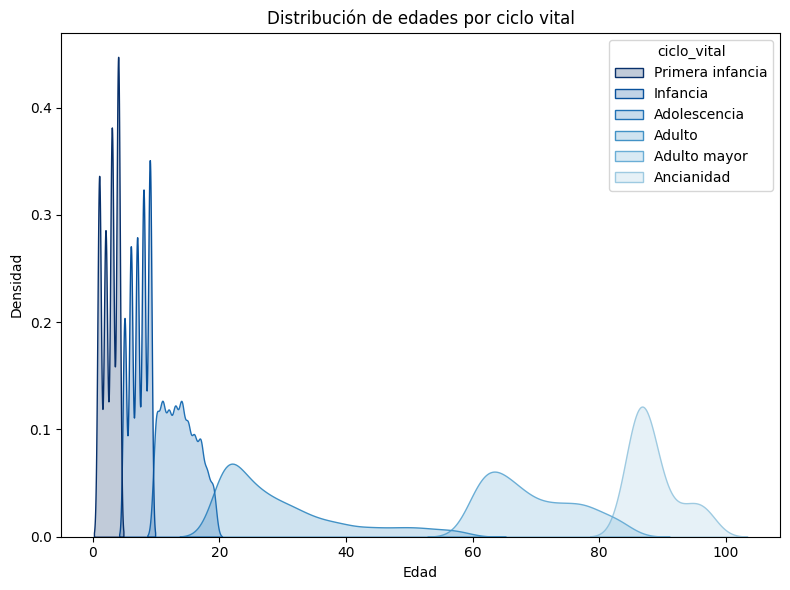

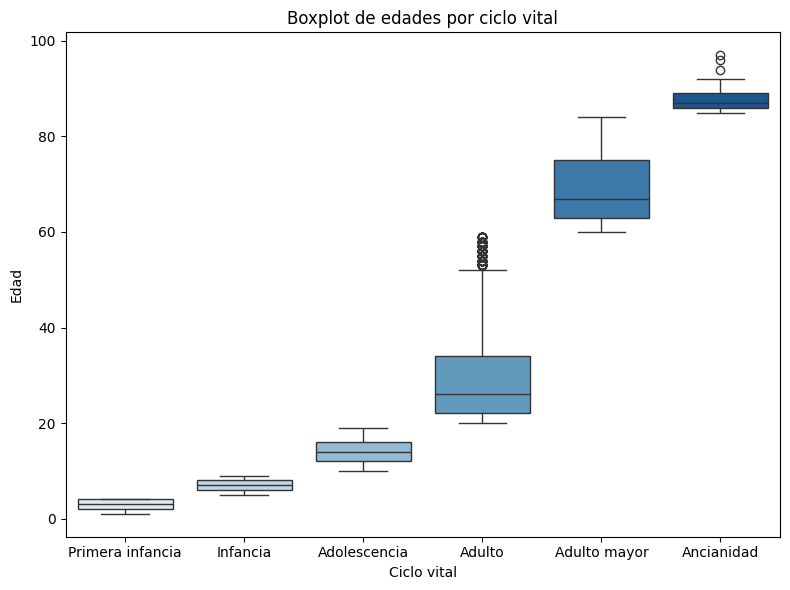

In [22]:
# [Gráfico] Distribución de edad
def graficos(df, variable, grupo):
    """
    Genera:
    1. Histograma + densidad global
    2. Densidad por ciclo vital
    3. Boxplot por ciclo vital
    """
    palette = ["#08306B", "#08519C", "#2171B5", "#4292C6", "#6BAED6", "#9ECAE1"]

    # --- 2. Densidad por ciclo vital ---
    plt.figure(figsize=(8,6))
    sns.kdeplot(data=df, x=variable, hue=grupo, common_norm=False, fill=True, palette=palette)
    plt.title("Distribución de edades por ciclo vital")
    plt.xlabel("Edad")
    plt.ylabel("Densidad")
    plt.tight_layout()
    plt.show()

    # --- 3. Boxplot por ciclo vital ---
    plt.figure(figsize=(8,6))
    sns.boxplot(data=df, x=grupo, hue=grupo, y=variable, palette="Blues")
    plt.title("Boxplot de edades por ciclo vital")
    plt.xlabel("Ciclo vital")
    plt.ylabel("Edad")
    plt.tight_layout()
    plt.show()

graficos(df_edad, variable="edad_años", grupo="ciclo_vital")

Los gráficos representan la distribución de la edad, discriminada por grupos etarios, donde se evidencia que para las primeras etapas de la vida, la distribución de la edad de los pacientes es homogénea. La etapa adulta es la de mayor variabilidad, con sesgo positivo, lo que indica una mayor proporción de casos hacia los adultos mas jóvenes. Misma dinámica se aprecia para el grupo Adulto mayor y Ancianidad.

### **Variables de evento**

In [16]:
print("DESCRIPCIÓN DE VARIABLES DE EVENTO")
describir_categorica(df['evento'])
describir_categorica(df['tipo_de_caso'])
describir_categorica(df['hospitalizacion'])
describir_categorica(df['desenlace'])

DESCRIPCIÓN DE VARIABLES DE EVENTO

📌 Variable: evento
         Conteo  Proporción  Clasico  Grave  Prop_Clasico  Prop_Grave
evento                                                               
Clasico   18160       0.978    18160      0           1.0         0.0
Grave       418       0.022        0    418           0.0         1.0

-----------------------------------

📌 Variable: tipo_de_caso
                       Conteo  Proporción  Clasico  Grave  Prop_Clasico  \
tipo_de_caso                                                              
Probable                13613       0.733    13313    300         0.978   
Conf. por laboratorio    4912       0.264     4794    118         0.976   
Conf. por nexo             53       0.003       53      0         1.000   

                       Prop_Grave  
tipo_de_caso                       
Probable                    0.022  
Conf. por laboratorio       0.024  
Conf. por nexo              0.000  

-----------------------------------

📌 Variab

El dengue clásico en el Atlántico tiene una representatividad del 97.8% de casos (181,158) frente al 2.3% de casos graves (418) en todo el territorio. En su mayoría los registros analizados corresponden a casos probables (73.3%), solo el 26.4% fueron casos confirmados por prueba en laboratorio. Todos los casos confirmados por nexo epidemiológico (53) se relacionan al dengue clásico. 

De los casos registrados, se tiene que solo el 58.5% de los pacientes requirieron hospitalización, mientras que el 41.5% fueron manejados de manera ambulatoria. De los 418 casos de dengue grave, 10 no fueron hospitalizados. 

En relación a los fallecidos, la mortalidad registrada es mínima, existiendo solo 7 pacientes fallecidos, todos por dengue grave.

### **Variables espaciales**

> Existen 27 registros con municipio 'desconocido' el cual no pudo identificarse en el preprocesamiento. Para este análisis se excluirán de los resultados.

#### *Casos netos*

In [ ]:
print("DESCRIPCIÓN DE VARIABLES ESPACIALES")

describir_categorica(df["area"])
describir_categorica(df['municipio'])
describir_categorica(df['subregion'])

DESCRIPCIÓN DE VARIABLES ESPACIALES

📌 Variable: area
                    Conteo  Proporción  Clasico  Grave  Prop_Clasico  \
area                                                                   
Cabecera municipal   17841       0.960    17439    402         0.977   
Centro Poblado         644       0.035      630     14         0.978   
Rural disperso          93       0.005       91      2         0.978   

                    Prop_Grave  
area                            
Cabecera municipal       0.023  
Centro Poblado           0.022  
Rural disperso           0.022  

-----------------------------------

📌 Variable: municipio
                  Conteo  Proporción  Clasico  Grave  Prop_Clasico  Prop_Grave
municipio                                                                     
SOLEDAD             8791       0.473     8624    167         0.981       0.019
MALAMBO             2087       0.112     2045     42         0.980       0.020
BARANOA             1207       0.065     118

Los casos de dengue se registraron en su mayoría en una cabecera municipal (96%), siendo solo el 4% en un centro poblado o rural disperso. 

La dinámica por municipios es variada, en datos netos, los municipios metropolitanos de Soledad y Malambo registran la mayor cantidad de casos de dengue clásico y grave. La mitad de los casos se concentra en el municipio de Soledad (47.3%) con 8,623 casos, de los cuales 167 son de dengue grave. 

Luego, los municipios de Baranoa, Sabanalarga y Galapa, constituyen un bloque de más de 1,000 casos reportados, representando cada uno un 6% del total de casos, conformando el núcleo de mayor transmisión. Cabe resaltar que en el municipio de Puerto Colombia, se registro la mayor cantidad de casos graves (57) después de Soledad. 

Con menor representatividad, sin superar los 100 registros, se encuentran los municipios de Candelaria, Piojó y Santa Lucía, este último, no presenta casos por dengue grave. 

En resumen, la epidemia de dengue en el departamento del Atlántico presenta un patrón predominante urbano, con concentración en los municipios del área metropolitana y céntrica, lo cual podría reflejar tanto características locales de transmisión como posibles diferencias en el acceso a diagnóstico oportuno.

#### _Municipio_

In [ ]:
# [Tabla] Casos por municipio
tabla_mun = df.groupby(["municipio", "año", "evento"]).size().reset_index(name="casos")
totales_mun = tabla_mun.groupby("municipio")["casos"].sum()

In [24]:
totales_mun.describe()

count      22.000000
mean      585.818182
std      1222.803167
min        33.000000
25%        79.250000
50%       136.500000
75%       641.750000
max      5747.000000
Name: casos, dtype: float64

Tomando el total de casos, por cada municipio se registraron como mínimo 27 eventos y máximo 8,791. En promedio se tiene un registro de 808 casos por municipio, con una desviación alta de 1,815 registros. El 50% de los municipios tiene un reporte entre 124 a 694 casos.

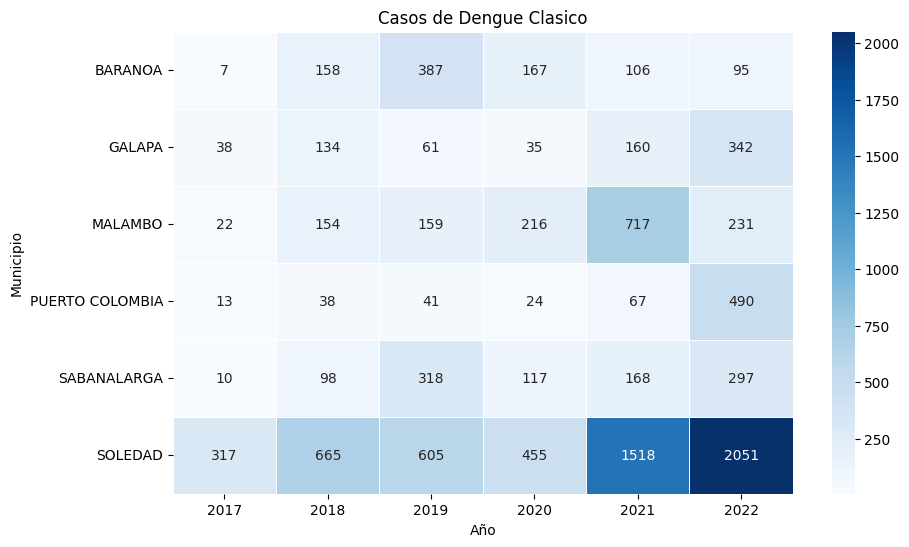

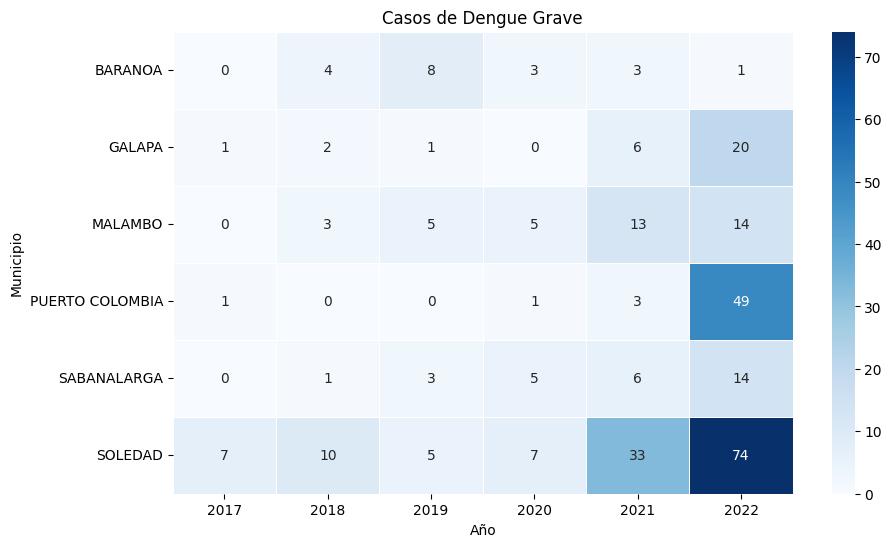

In [25]:
# [Gráfico] Tabla casos por municipio

totales_mun = tabla_mun.groupby("municipio")["casos"].sum()
municipios_filtrados = totales_mun[totales_mun > 650].index
tabla_filtrada = tabla_mun[tabla_mun["municipio"].isin(municipios_filtrados)]

eventos = ["Clasico", "Grave"]

for evento in eventos:
    tabla_evento = tabla_filtrada[tabla_filtrada["evento"] == evento]

    # Crear tabla pivote
    pivot = tabla_evento.pivot_table(
        index="municipio", 
        columns="año", 
        values="casos", 
        fill_value=0
    ).astype(int)

    # Graficar
    plt.figure(figsize=(10,6))
    sns.heatmap(pivot, cmap="Blues", linewidths=0.5, annot=True, fmt="d")
    plt.title(f"Casos de Dengue {evento}")
    plt.xlabel("Año")
    plt.ylabel("Municipio")
    plt.show()


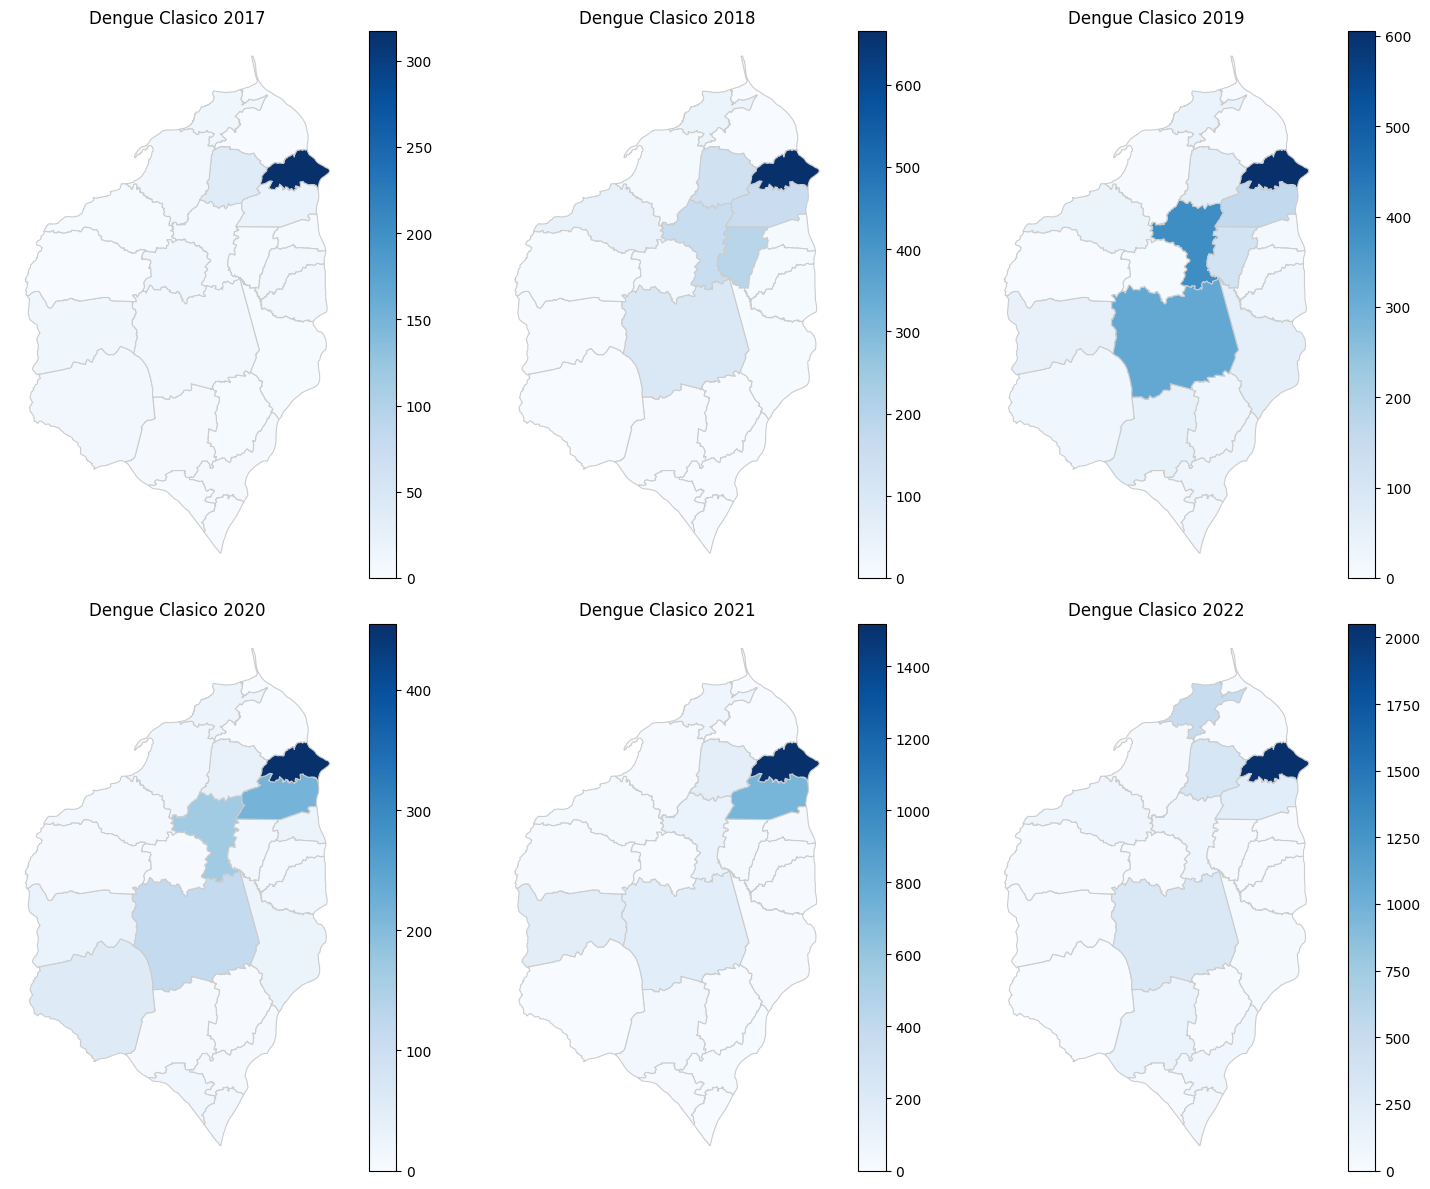

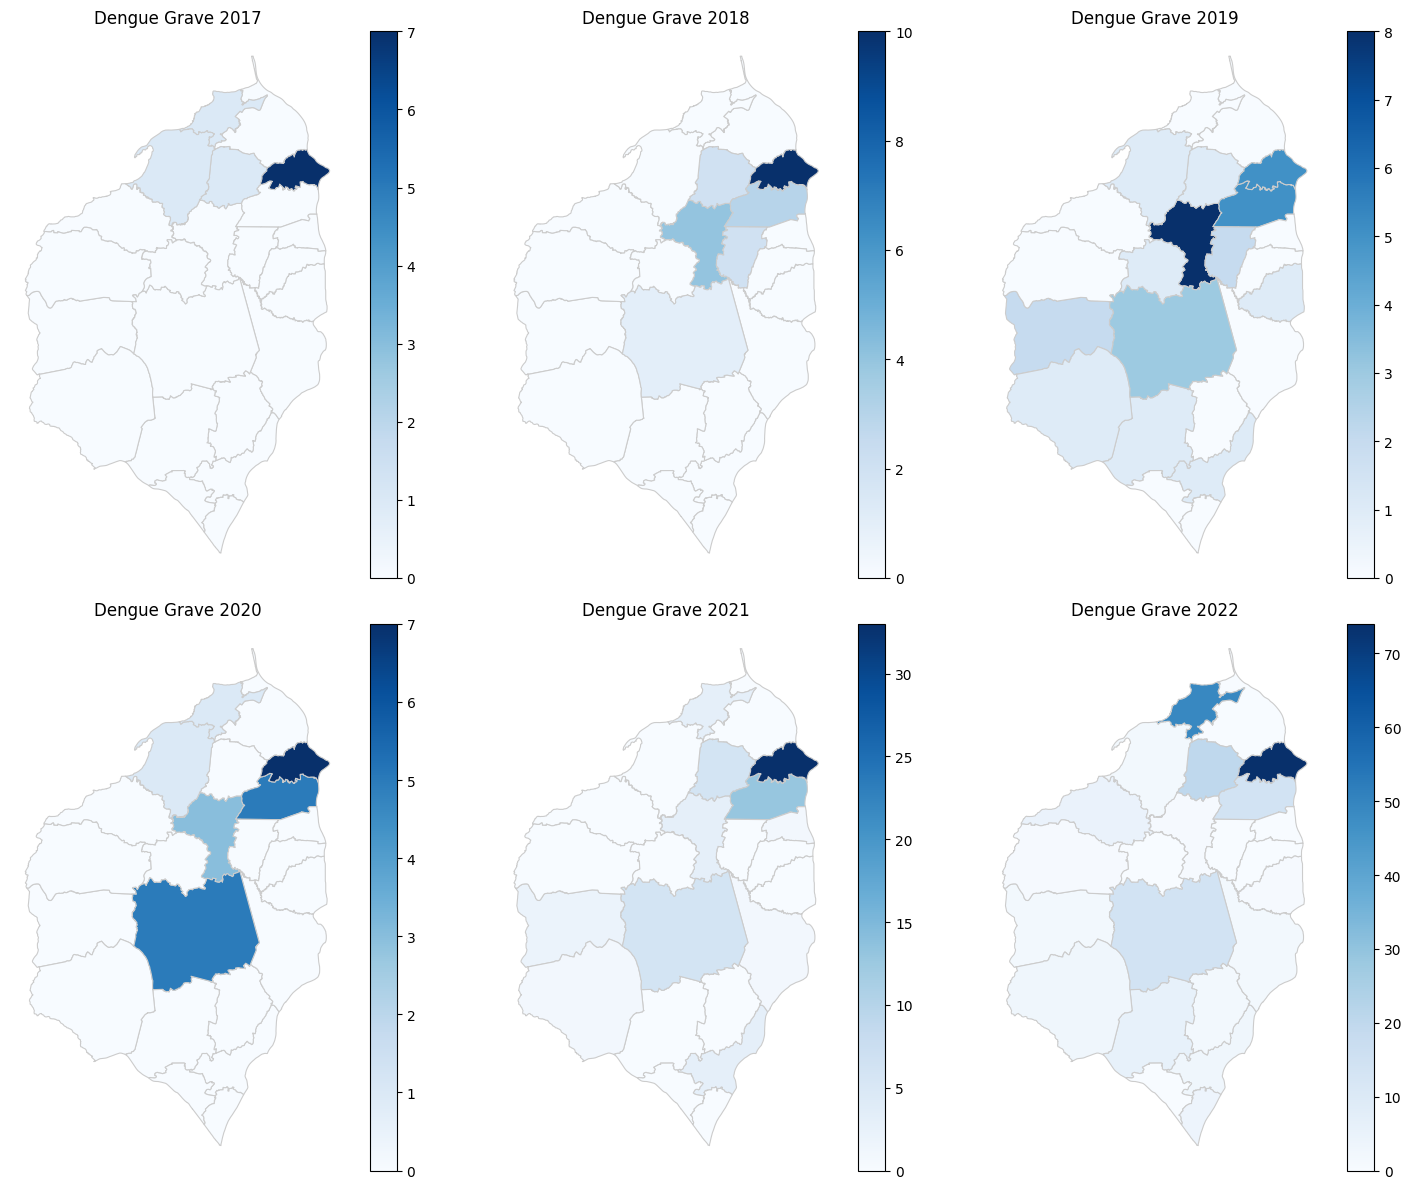

In [29]:
eventos = ["Clasico", "Grave"]

for evento in eventos:
    anios = sorted(df["año"].unique())[:6]  # Solo los primeros 6 años
    n = len(anios)

    columnas = 3
    filas = (n + columnas - 1) // columnas

    fig, axes = plt.subplots(filas, columnas, figsize=(5*columnas, 6*filas))
    axes = axes.flatten()

    for i, anio in enumerate(anios):
        casos_anio = (
            df[(df["año"] == anio) & (df["evento"] == evento)]
            .groupby("municipio")
            .size()
            .reset_index(name="CASOS")
        )

        gdf_plot = gdf.merge(casos_anio, on="municipio", how="left").fillna(0)

        gdf_plot.plot(column="CASOS", cmap="Blues", linewidth=0.8, edgecolor="0.8",
                      legend=True, ax=axes[i])
        axes[i].set_title(f"Dengue {evento} {anio}")
        axes[i].axis("off")

    # Ocultar subplots vacíos (si sobran)
    for j in range(len(anios), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

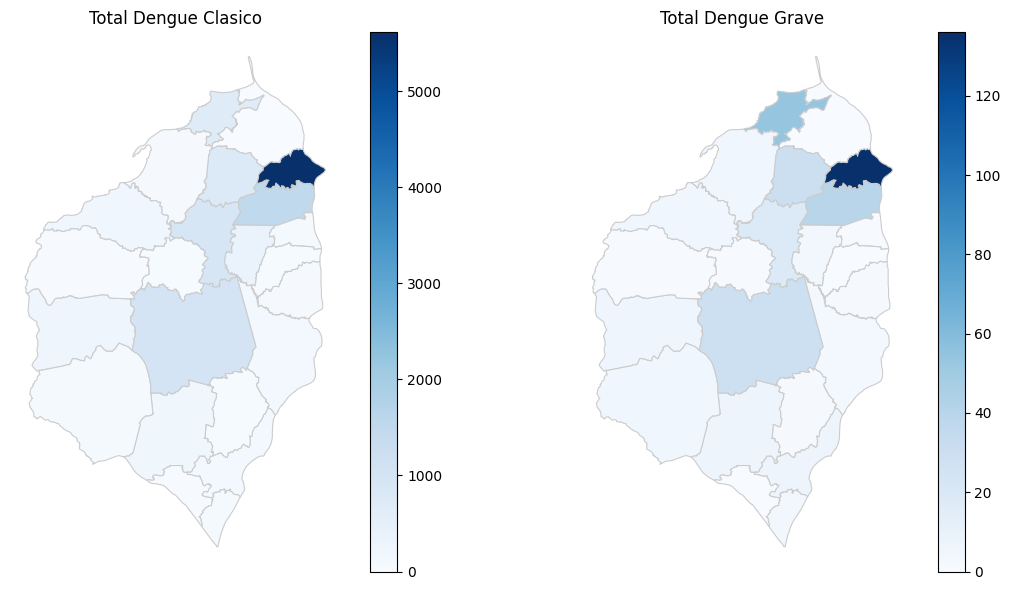

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 fila, 2 columnas
axes = axes.flatten()

for i, evento in enumerate(eventos):
    casos_total = (
        df[df["evento"] == evento]
        .groupby("municipio")
        .size()
        .reset_index(name="CASOS")
    )

    gdf_total = gdf.merge(casos_total, on="municipio", how="left").fillna(0)

    gdf_total.plot(column="CASOS", cmap="Blues", linewidth=0.8, edgecolor="0.8",
                   legend=True, ax=axes[i])
    axes[i].set_title(f"Total Dengue {evento}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


#### _Subregión_

In [31]:
# [Tabla] Casos por sub-región
tabla_rg = df.groupby(["subregion", "año", "evento"]).size().reset_index(name="casos")
totales_rg = tabla_rg.groupby("subregion")["casos"].sum()

In [33]:
totales_rg.describe()

count       5.000000
mean     2577.600000
std      3619.189039
min       334.000000
25%       375.000000
50%       676.000000
75%      2690.000000
max      8813.000000
Name: casos, dtype: float64

Tomando el total de casos, por cada sub región se registraron como mínimo 27 eventos y máximo 8,791. En promedio se tiene un registro de 808 casos por municipio, con una desviación alta de 1,815 registros. El 50% de los municipios tiene un reporte entre 124 a 694 casos.

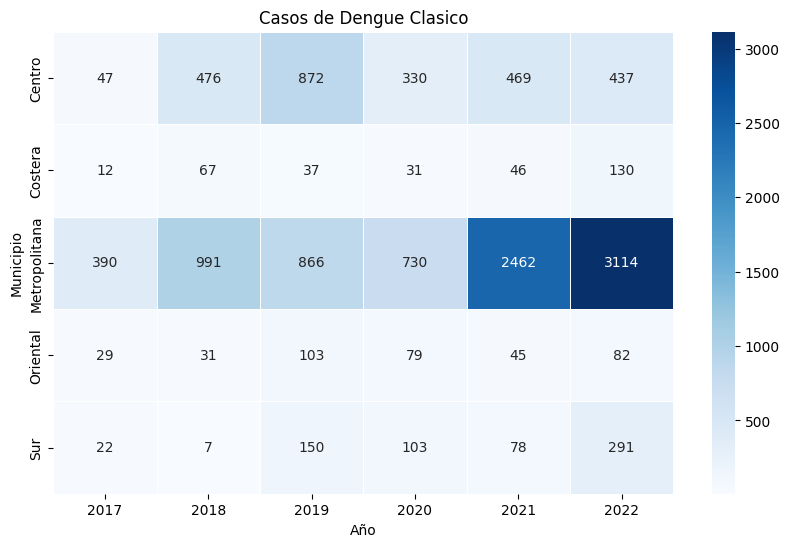

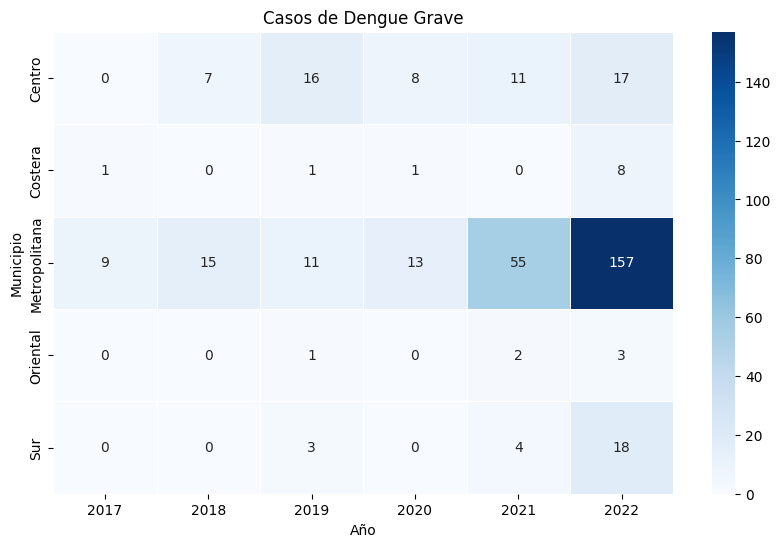

In [38]:
# [Gráfico] Tabla casos por subregion
eventos = ["Clasico", "Grave"]

for evento in eventos:
    tabla_evento = tabla_rg[tabla_rg["evento"] == evento]

    # Crear tabla pivote: subregión vs año
    pivot = tabla_evento.pivot_table(
        index="subregion", 
        columns="año", 
        values="casos", 
        fill_value=0
    ).astype(int)

    # Graficar
    plt.figure(figsize=(10,6))
    sns.heatmap(pivot, cmap="Blues", linewidths=0.5, annot=True, fmt="d")
    plt.title(f"Casos de Dengue {evento}")
    plt.xlabel("Año")
    plt.ylabel("Municipio")
    plt.show()


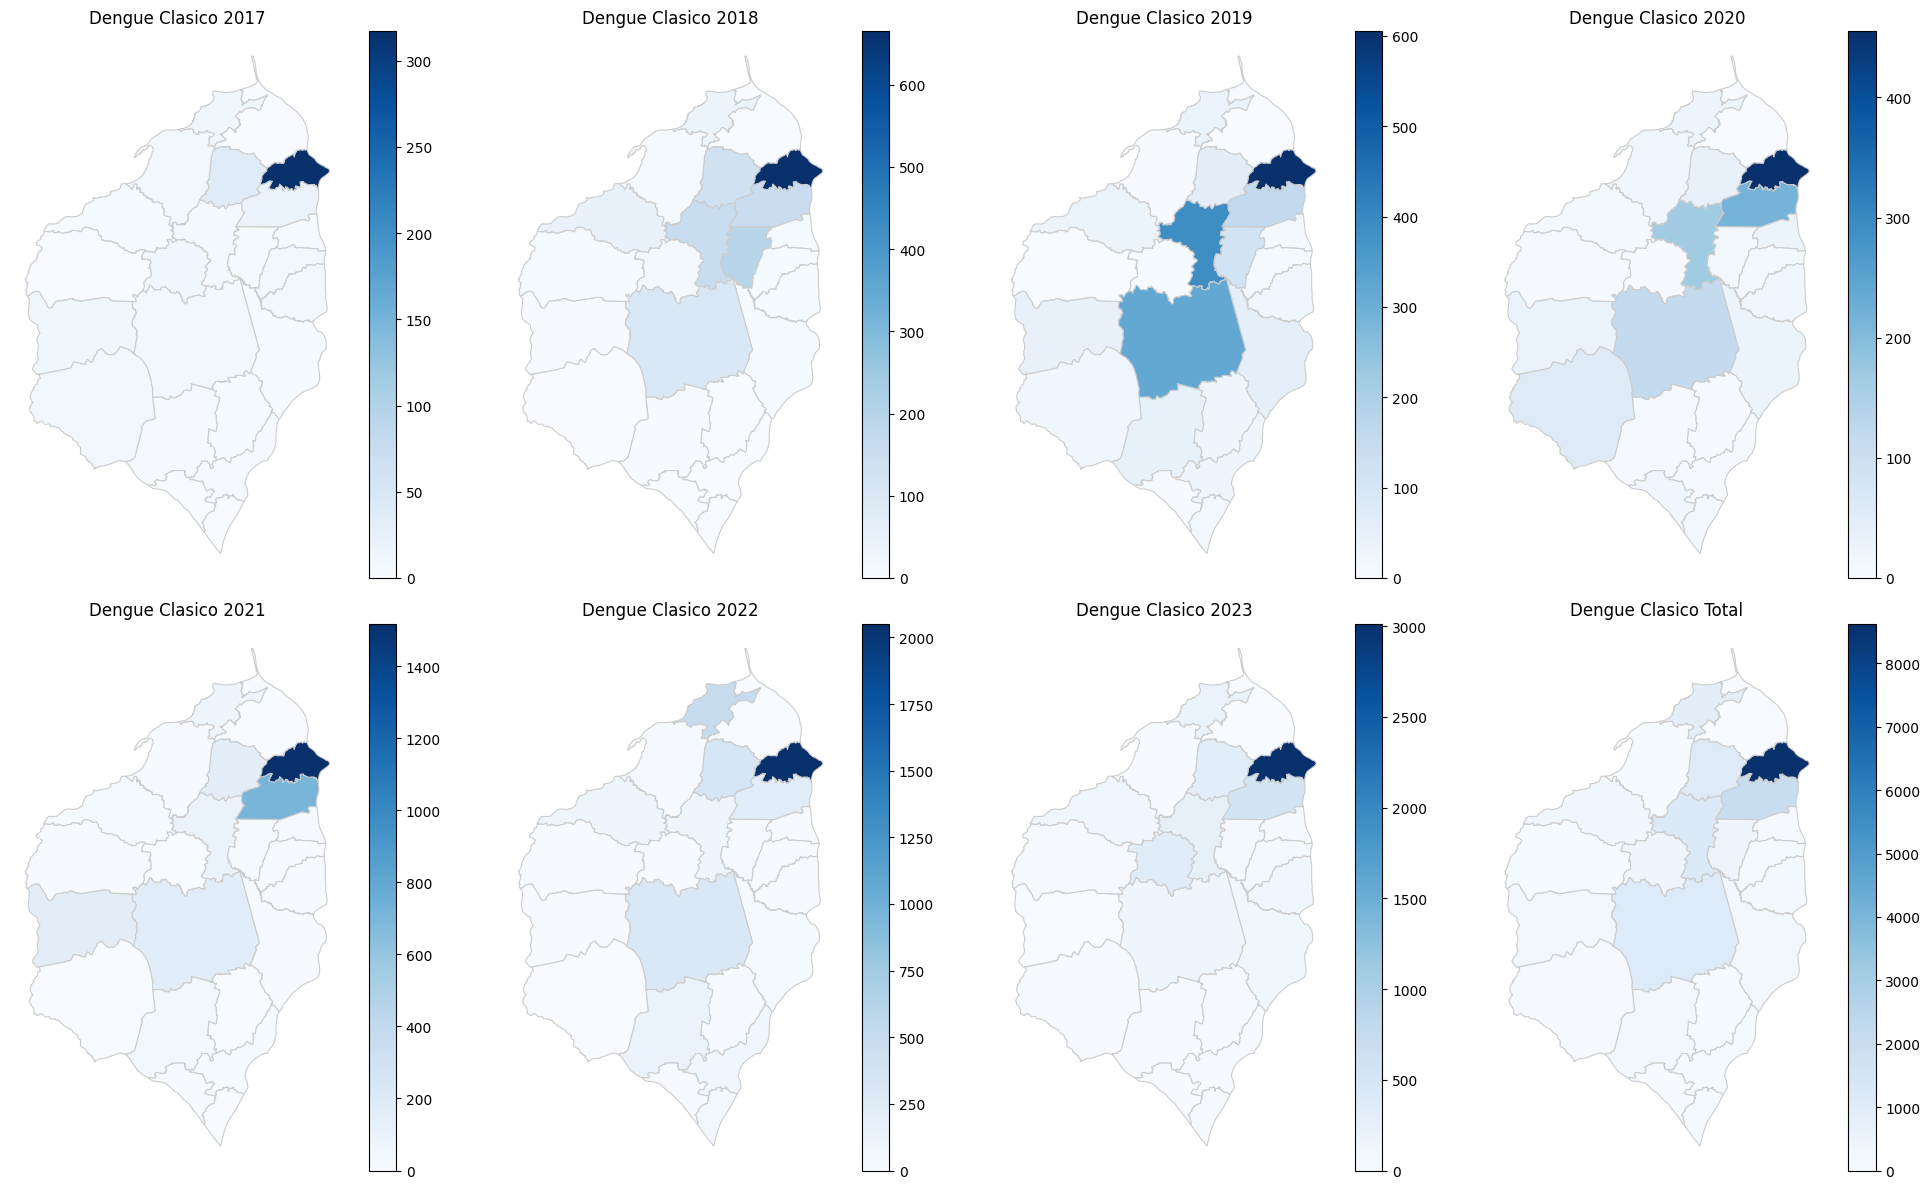

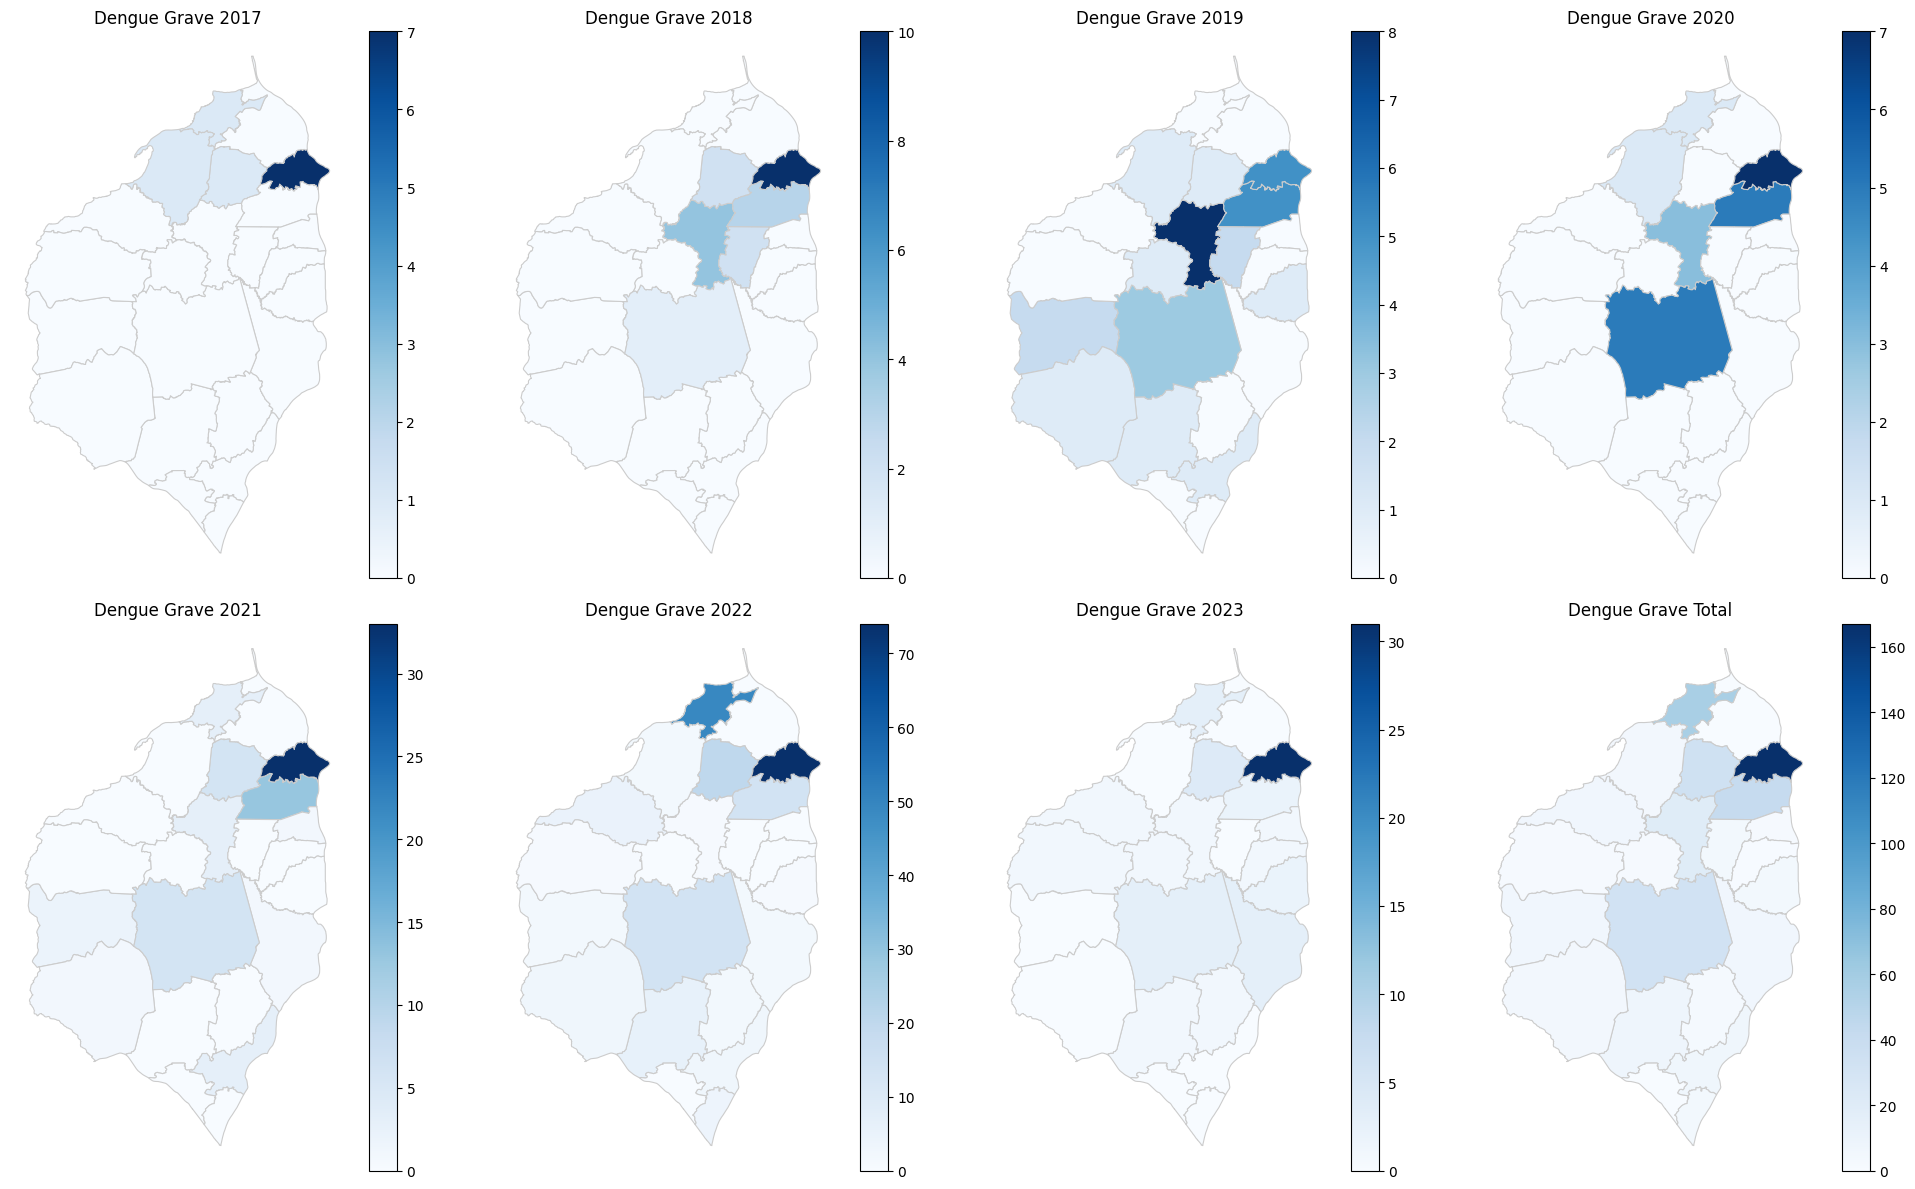

In [ ]:
# [Gráfico] Mapa casos por municipio según evento

eventos = ["Clasico", "Grave"]

for evento in eventos:
    anios = sorted(df["año"].unique())
    n = len(anios) + 1  # años + total

    # Calcular número de filas y columnas dinámicamente
    columnas = 4
    filas = (n + columnas - 1) // columnas

    fig, axes = plt.subplots(filas, columnas, figsize=(5*columnas, 6*filas))
    axes = axes.flatten()

    # Mapas por año
    for i, anio in enumerate(anios):
        casos_anio = (
            df[(df["año"] == anio) & (df["evento"] == evento)]
            .groupby("municipio")
            .size()
            .reset_index(name="CASOS")
        )

        gdf_plot = gdf.merge(casos_anio, on="municipio", how="left").fillna(0)

        gdf_plot.plot(column="CASOS", cmap="Blues", linewidth=0.8, edgecolor="0.8",
                      legend=True, ax=axes[i])
        axes[i].set_title(f"Dengue {evento} {anio}")
        axes[i].axis("off")

    # Mapa total por evento
    casos_total = (
        df[df["evento"] == evento]
        .groupby("municipio")
        .size()
        .reset_index(name="CASOS")
    )

    gdf_total = gdf.merge(casos_total, on="municipio", how="left").fillna(0)

    gdf_total.plot(column="CASOS", cmap="Blues", linewidth=0.8, edgecolor="0.8",
                   legend=True, ax=axes[-1])
    axes[-1].set_title(f"Dengue {evento} Total")
    axes[-1].axis("off")

    # Ocultar subplots vacíos (si sobran)
    for j in range(len(anios) + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


#### *Casos por densidad poblacional*

In [39]:
# [Tabla] Casos por municipio
tabla_mun = df.groupby(["municipio", "año", "evento"]).size().reset_index(name="casos")

# Ajustar nombres de columna para unir
poblacion = poblacion.rename(columns={'MUNICIPIO':'municipio', 'TOTAL':'total_pob'})

# Convertir columnas de año en una columna 'año'
poblacion_long = poblacion.melt(
    id_vars=['municipio', 'total_pob'],    # mantener municipio y total
    value_vars=['2017.0','2018.0','2019.0','2020.0','2021.0','2022.0','2023.0'],
    var_name='año',
    value_name='poblacion'
)

# Asegurarse de que 'año' sea numérico
poblacion_long['año'] = poblacion_long['año'].astype(float).astype(int)

# Unir casos con población del mismo año
tabla_mun = tabla_mun.merge(poblacion_long, on=['municipio','año'], how='left')

# Densidad por año y municipio
tabla_mun['densidad'] = tabla_mun['casos'] / tabla_mun['poblacion']

# Si quieres por cada 1000 habitantes
tabla_mun['densidad'] = (tabla_mun['casos'] / tabla_mun['poblacion']) * 1000

tabla_mun = tabla_mun.sort_values(by='densidad', ascending=False)

In [40]:
# Densidad global por municipio (todos los años)
densidad_global = tabla_mun.groupby("municipio").agg(
    casos_totales=('casos', 'sum'),
    poblacion_total=('total_pob', 'first')   # la misma población total por municipio
).reset_index()

densidad_global['densidad_global'] = (densidad_global['casos_totales'] / densidad_global['poblacion_total']) * 10000

# Ordenar de mayor a menor
densidad_global = densidad_global.sort_values(by='densidad_global', ascending=False)

densidad_global.head(10)


,municipio,casos_totales,poblacion_total,densidad_global
10,POLONUEVO,386,155707.0,24.790151
0,BARANOA,939,539600.0,17.401779
12,PUERTO COLOMBIA,727,443890.0,16.377931
3,GALAPA,800,519297.0,15.405442
6,MALAMBO,1539,1105302.0,13.923796
15,SABANALARGA,1037,785276.0,13.205548
4,JUAN DE ACOSTA,221,178618.0,12.372773
5,LURUACO,278,240991.0,11.535701
18,SOLEDAD,5747,5229151.0,10.990312
19,SUAN,105,103469.0,10.147967


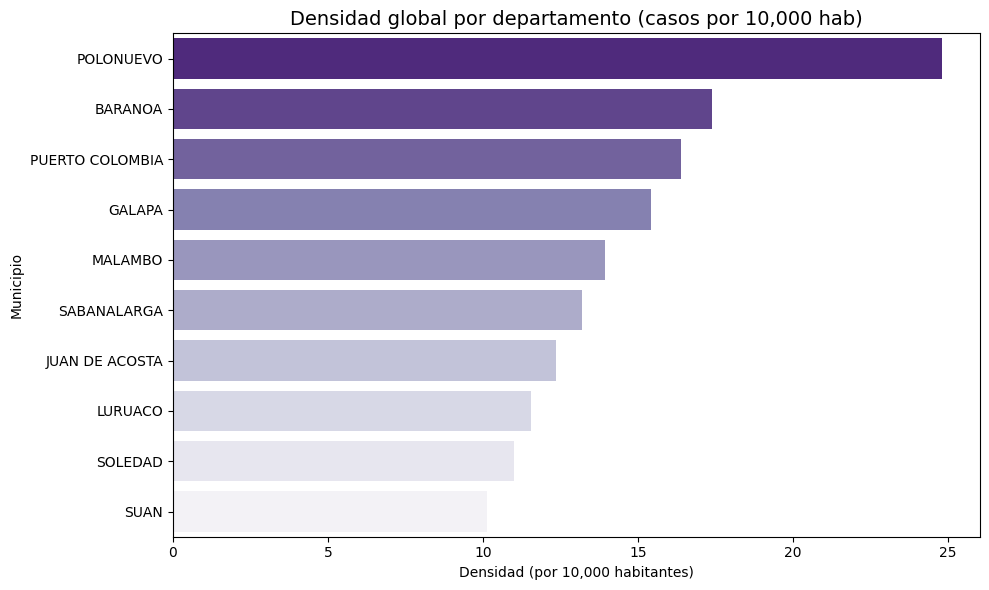

In [41]:
top10 = densidad_global.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top10, x='densidad_global', y='municipio', hue='municipio', palette='Purples_r')

plt.title("Densidad global por departamento (casos por 10,000 hab)", fontsize=14)
plt.xlabel("Densidad (por 10,000 habitantes)")
plt.ylabel("Municipio")
plt.tight_layout()
plt.show()


In [42]:
densidad_global['densidad_global'].describe()

count    15.000000
mean     11.310723
std       6.022226
min       3.139106
25%       6.824233
50%      11.535701
75%      14.664619
max      24.790151
Name: densidad_global, dtype: float64

<Axes: xlabel='densidad_global'>

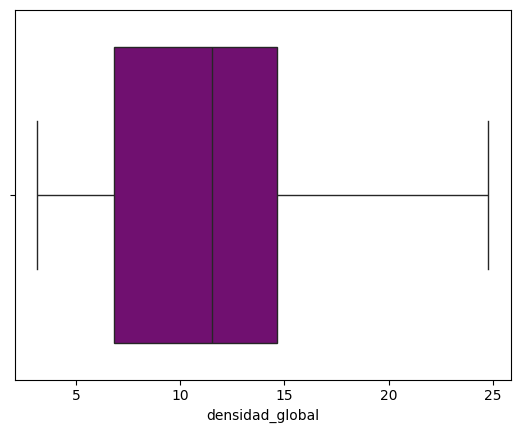

In [43]:
sns.boxplot(data=densidad_global, x='densidad_global', color='Purple')

La densidad poblacional de casos de dengue por municipio presenta una gran variabilidad. El valor promedio es de aproximadamente 14.3 casos por cada 10,000 habitantes, con una desviación estándar de 8.4 casos. Un 25% de los municipios reporta entre 7 a 14.3 casos, mostrando entonces la mitad de los territorios no reportan más de 15 casos por cada 10,000 habitantes. El municipio de Usiacurí es el de mayor densidad de casos (37), este es un dato atípico al conjunto, representando una tasa muy alta. La distribución de la densidad es sesgada hacia la derecha, con municipios de Polovuevo, Baranoa, Galapa y Puerto Colombia reportando más de 20 casos por cada 10,000 habitantes. 

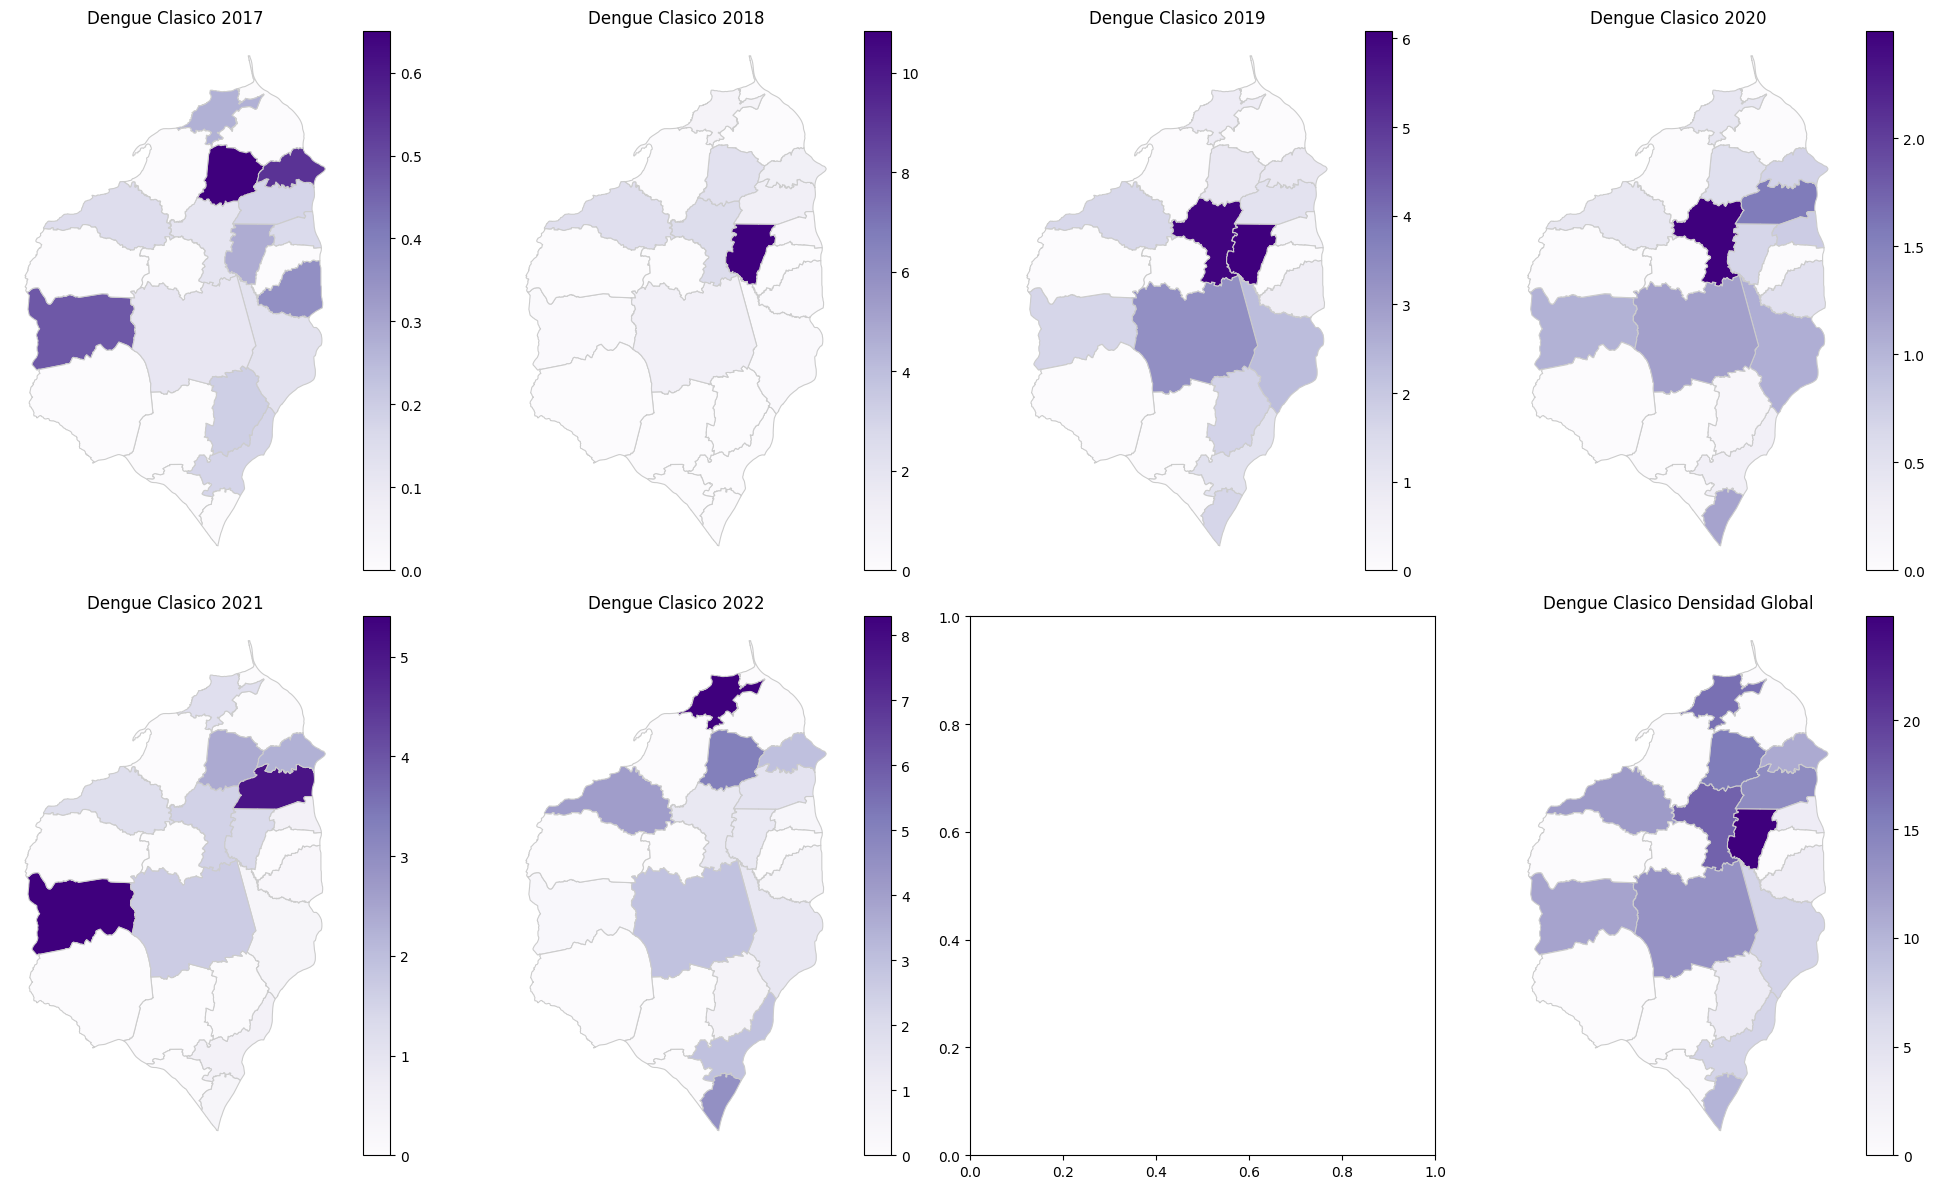

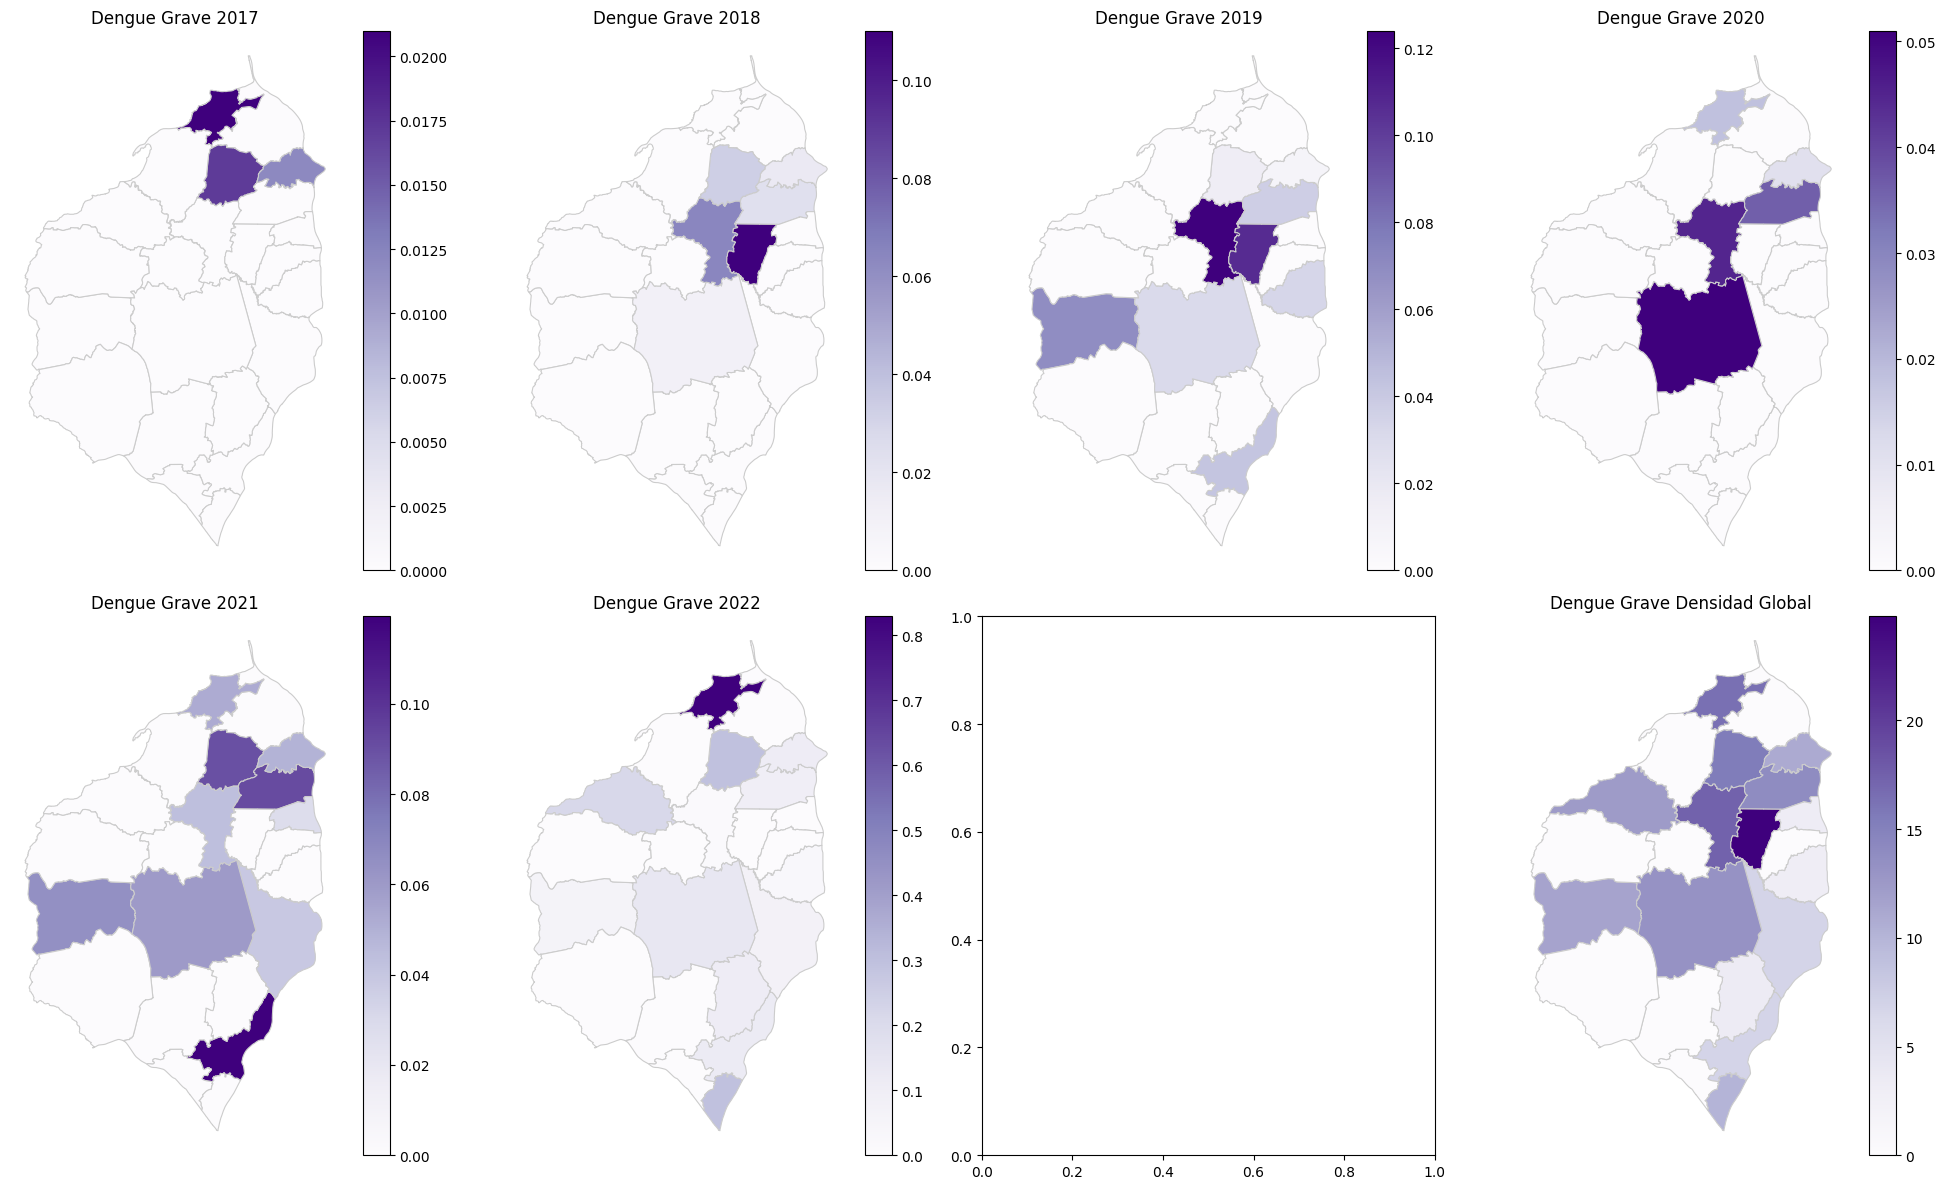

In [44]:
# [Gráfico] Mapa casos por municipio según evento

eventos = ["Clasico", "Grave"]

for evento in eventos:
    anios = sorted(df["año"].unique())
    n = len(anios) + 1  # años + total

    # Calcular número de filas y columnas dinámicamente
    columnas = 4
    filas = (n + columnas - 1) // columnas

    fig, axes = plt.subplots(filas, columnas, figsize=(5*columnas, 6*filas))
    axes = axes.flatten()

    # Mapas por año
    for i, anio in enumerate(anios):
        casos_anio = (
            tabla_mun[(tabla_mun["año"] == anio) & (tabla_mun["evento"] == evento)]
            .groupby("municipio")["densidad"].sum()   # sumar densidad por municipio
            .reset_index()
        )

        gdf_plot = gdf.merge(casos_anio, on="municipio", how="left").fillna(0)

        gdf_plot.plot(column="densidad", cmap="Purples", linewidth=0.8, edgecolor="0.8",
                      legend=True, ax=axes[i])
        axes[i].set_title(f"Dengue {evento} {anio}")
        axes[i].axis("off")

    gdf_total = gdf.merge(densidad_global[['municipio','densidad_global']], on="municipio", how="left").fillna(0)
    gdf_total.plot(column="densidad_global", cmap="Purples", linewidth=0.8, edgecolor="0.8",
                legend=True, ax=axes[-1])
    axes[-1].set_title(f"Dengue {evento} Densidad Global")
    axes[-1].axis("off")


    # Ocultar subplots vacíos (si sobran)
    for j in range(len(anios) + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


### **Variables temporales**

In [45]:
describir_categorica(df["año"])


📌 Variable: año
      Conteo  Proporción  Clasico  Grave  Prop_Clasico  Prop_Grave
año                                                               
2022    4257       0.330     4054    203         0.952       0.048
2021    3172       0.246     3100     72         0.977       0.023
2019    2060       0.160     2028     32         0.984       0.016
2018    1594       0.124     1572     22         0.986       0.014
2020    1295       0.100     1273     22         0.983       0.017
2017     510       0.040      500     10         0.980       0.020

-----------------------------------


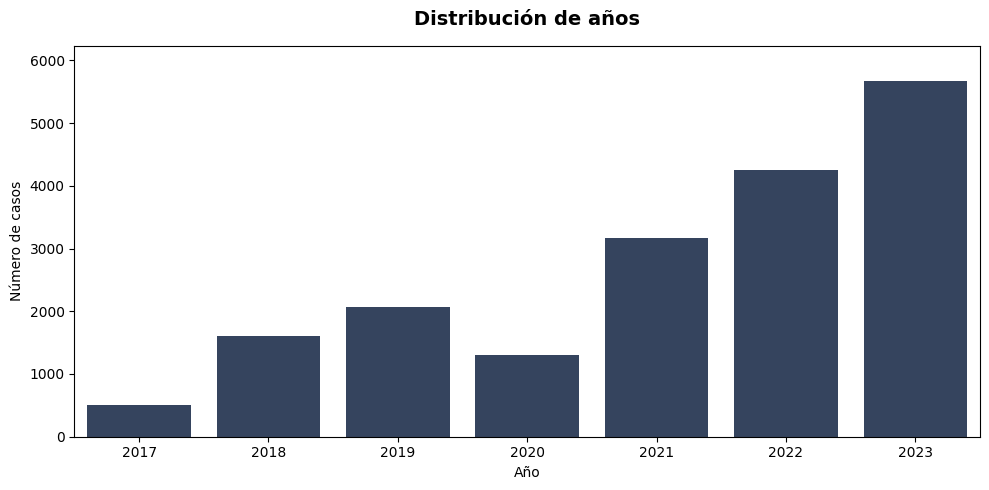

In [22]:
# [Gráfico] Distribución por años
conteo_por_año = df['año'].value_counts(sort=False).sort_index()

    # Crear gráfico
plt.figure(figsize=(10, 5))
sns.barplot(x=conteo_por_año.index.astype(str), y=conteo_por_año.values, color='#2E4265')

plt.title('Distribución de años', fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Año")
plt.ylabel("Número de casos")
plt.xticks(rotation=0)
plt.ylim(0, max(conteo_por_año.values) * 1.1)
plt.tight_layout()
plt.show()


La variabilidad de los casos en el tiempo, muestra una notoria tendencia hacía la alza al pasar de los años, con variaciones importantes. Del 2017 al 2019, se obtienen la menor cantidad de registros, solo el 27% de los casos se dieron en este tiempo. En este periodo se evidencia un ciclo de crecimiento con caída hacia el 2020, para seguir la tendencia de crecimiento hacia el 2023. El año 2022, es el que mayor registro de casos de dengue grave presenta, unos 203 pacientes. 

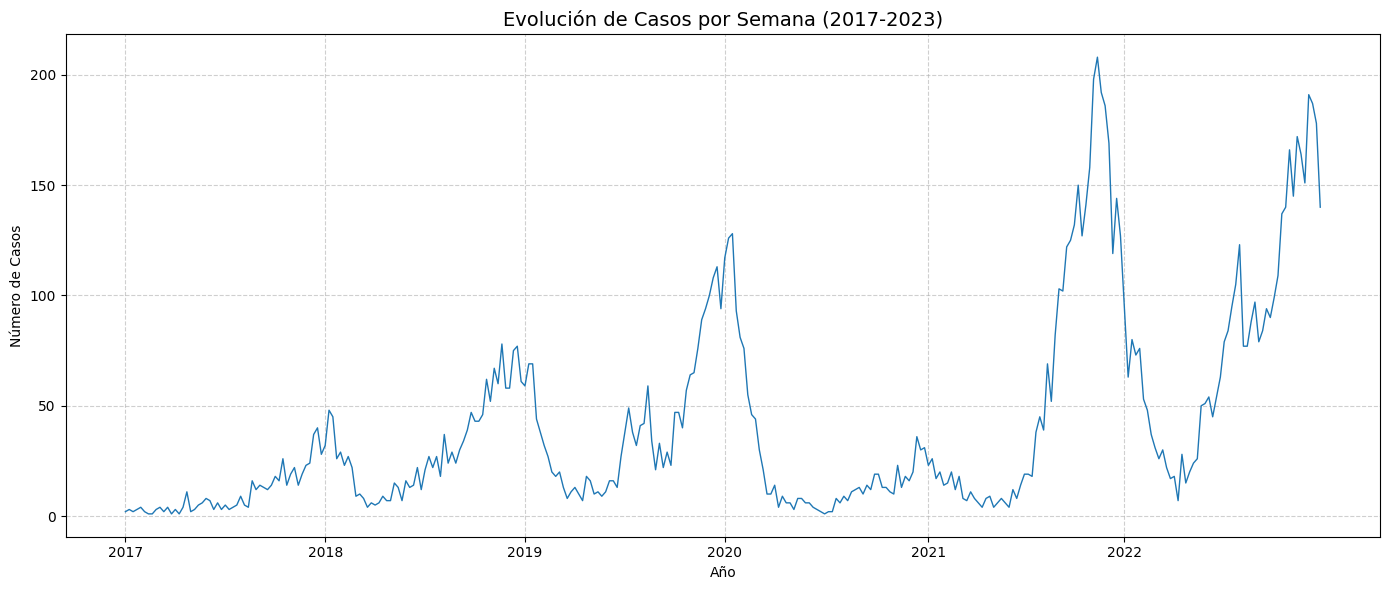

In [46]:
# [Gráfico] Casos por semana
casos_semana = df.groupby(["año", "semana"]).size().reset_index(name="casos")
casos_semana = casos_semana.sort_values(["año", "semana"]).reset_index(drop=True)
casos_semana["index"] = range(len(casos_semana))

# Graficar
plt.figure(figsize=(14, 6))
plt.plot(casos_semana["index"], casos_semana["casos"], linewidth=1)
años_unicos = casos_semana["año"].unique()
ticks = [casos_semana[casos_semana["año"] == año].index[0] for año in años_unicos]
plt.xticks(ticks, años_unicos, fontsize=10)
plt.title("Evolución de Casos por Semana (2017-2023)", fontsize=14)
plt.xlabel("Año")
plt.ylabel("Número de Casos")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

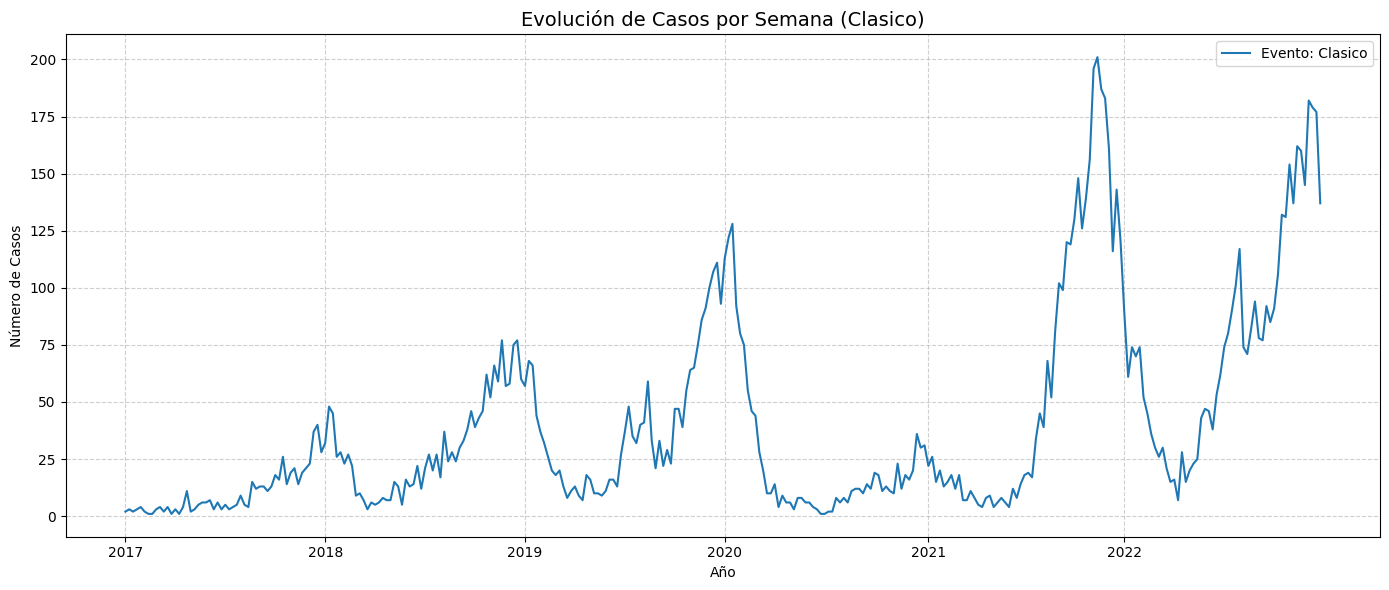

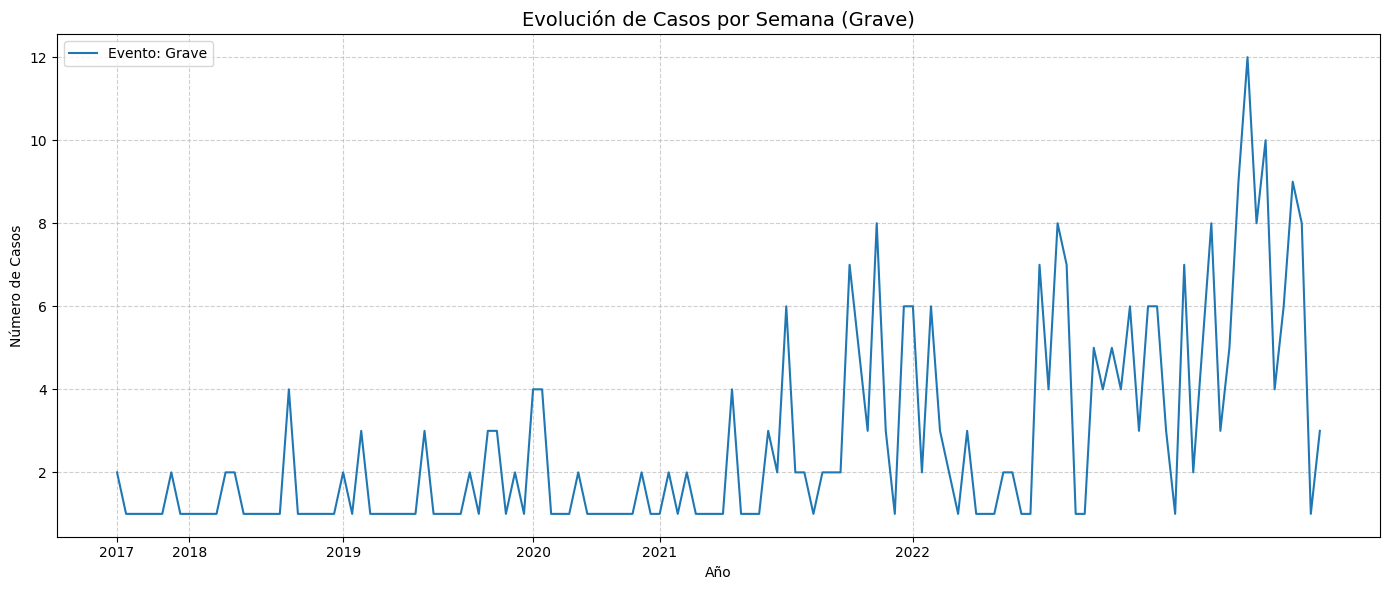

In [47]:
eventos = df["evento"].unique()

for ev in eventos:
    # Filtrar por evento
    df_evento = df[df["evento"] == ev]

    # Agrupar por semana y año
    casos_evento = df_evento.groupby(["año", "semana"]).size().reset_index(name="casos")
    casos_evento = casos_evento.sort_values(["año", "semana"]).reset_index(drop=True)
    casos_evento["index"] = range(len(casos_evento))

    # Graficar
    plt.figure(figsize=(14, 6))
    plt.plot(casos_evento["index"], casos_evento["casos"], linewidth=1.5, label=f"Evento: {ev}")
    
    años_unicos = casos_evento["año"].unique()
    ticks = [casos_evento[casos_evento["año"] == año].index[0] for año in años_unicos]
    plt.xticks(ticks, años_unicos, fontsize=10)

    plt.title(f"Evolución de Casos por Semana ({ev})", fontsize=14)
    plt.xlabel("Año")
    plt.ylabel("Número de Casos")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.legend()
    plt.show()

In [48]:
week = tabla_descriptiva(df_edad, variable="semana", grupo="año")
week

,año,n,media,mediana,sd,q25,q75,minimo,maximo
0,2017,503,38.37,42.0,12.61,33.0,48.5,1,52
1,2018,1585,33.62,39.0,16.09,24.0,47.0,1,52
2,2019,2047,32.74,38.0,16.95,21.0,47.0,1,52
3,2020,1287,17.04,7.0,18.23,3.0,35.0,1,53
4,2021,3158,39.97,43.0,11.15,37.0,47.0,1,52
5,2022,4245,33.81,38.0,15.08,26.0,46.0,1,52


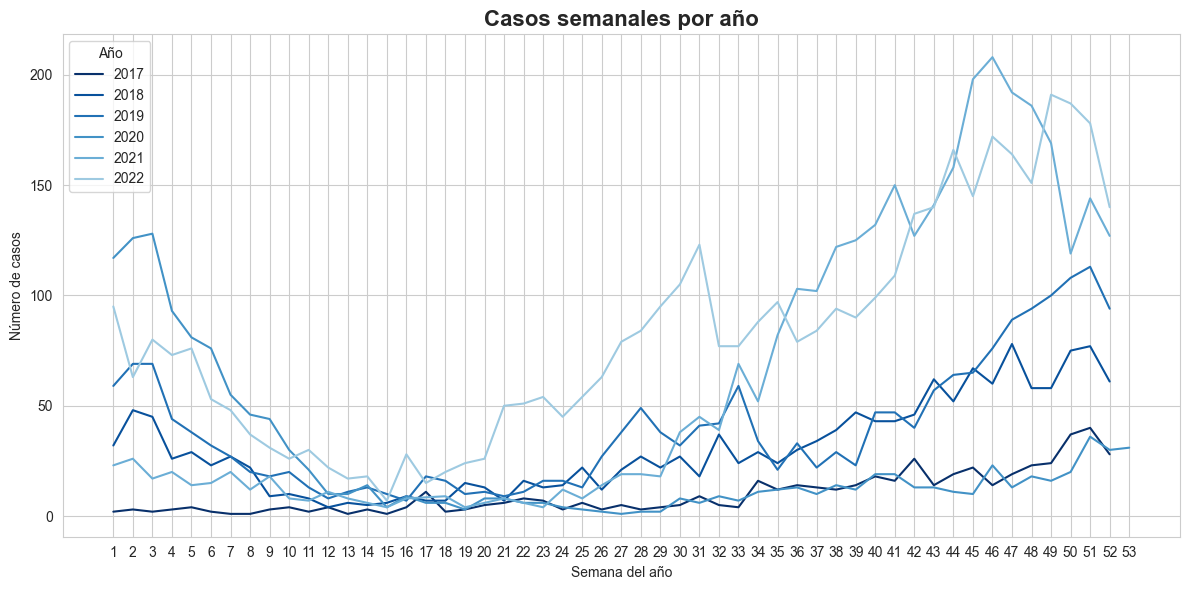

In [49]:
# Contar casos por semana y año
conteo_semanal = df.groupby(['año', 'semana']).size().reset_index(name='casos')

def graficar_casos_semanales_por_año(df_conteo, nombre_grafico="Casos semanales por año"):
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")

    años = sorted(df_conteo['año'].unique())
    
    palette = ["#08306B", "#08519C", "#2171B5", "#4292C6", "#6BAED6", "#9ECAE1", "#C6DBEF"]
    colores = palette[:len(años)]  # selecciona N colores según la cantidad de años

    for i, año in enumerate(años):
        datos_año = df_conteo[df_conteo['año'] == año]
        plt.plot(
            datos_año['semana'], 
            datos_año['casos'], 
            label=str(año), 
            color=colores[i]
        )
        
    plt.title(nombre_grafico, fontsize=16, fontweight='bold')
    plt.xlabel("Semana del año")
    plt.ylabel("Número de casos")
    plt.xticks(range(1, 54))  # Semanas ISO van de 1 a 53
    plt.legend(title="Año")
    plt.tight_layout()
    plt.show()


graficar_casos_semanales_por_año(conteo_semanal)

In [50]:
# Agrupar y pivotear
conteo_semanal_semanal = df.groupby(['año', 'semana']).size().reset_index(name='casos')
tabla_pivot = conteo_semanal.pivot(index='año', columns='semana', values='casos').fillna(0).astype(int)
# Crear lista para almacenar resultados
resumen_semanas = []
for año in tabla_pivot.index:
    fila = tabla_pivot.loc[año]
    semana_max = fila.idxmax()
    casos_max = fila.max()
    resumen_semanas.append({
        "año": año,
        "semana_más_casos": semana_max,
        "casos_máximos": casos_max,
    })
tabla_resumen = pd.DataFrame(resumen_semanas)
tabla_resumen


,año,semana_más_casos,casos_máximos
0,2017,51,40
1,2018,47,78
2,2019,51,113
3,2020,3,128
4,2021,46,208
5,2022,49,191


Al detallar los registros por la semana epidemiológica, se evidencia que existe un aumento de casos hacia los últimos meses de cada año, con algunos picos hacia la mitad del año. 

En promedio, los casos se dan en su mayoría entre la semana 28 y la semana 44, con una media de distribución hacia la semana 30. Se destaca que el record de casos fue de 250 en la primera semana del 2023.

Con respecto a cada año, la mayor variabilidad se evidencia en el 2023. Los años 2021 y 2022, presentan notados picos de alza hacia finales de cada año. El 2017 y el 2020, son los años de manor variabilidad.

## **2. Análisis estadístico**

In [52]:
demograficas = [
    "sexo",                    # M/F
    "edad_años",               # Edad numérica
    "ciclo_vital",             # Etapa de vida
    "grupo_etnico",            # Grupo étnico declarado
    "regimen_salud"            # Régimen (contributivo, subsidiado, etc.)
]

    # Variables del evento epidemiológico
evento = [
    "evento",                  # Clásico, grave
    "tipo_de_caso",               # Confirmado, probable, descartado
    "hospitalizacion",         # Sí/No
    "desenlace"                # Recuperado, fallecido, etc.
]

    # Variables de temporalidad
temporalidad = [
    "año",                     # Año del evento
    "semana",                  # Semana epidemiológica
    "periodo",                 # Periodo (cada 4 semanas)
    "fecha_inicio_sintomas",   # Inicio de síntomas
    "fecha_consulta",          # Fecha de consulta
    "fecha_hospitalizacion",   # Fecha de hospitalización
    "fecha_notificacion",      # Fecha de notificación
    "fecha_nacimiento"         # Fecha de nacimiento
]

    # Variables espaciales
espacial = [
    "municipio",                # Municipio de ocurrencia
    "area",                    # Urbana o rural
]

### **Pruebas de independencia de variables categóricas**

In [29]:
# [Test] Prueba de Chi-Cuadrado
def matriz_pvalores(df, variables, alpha=0.05):
    matriz = pd.DataFrame(index=variables, columns=variables)
    for var1 in variables:
        for var2 in variables:
            if var1 == var2:
                matriz.loc[var1, var2] = "-"
            else:
                tabla = pd.crosstab(df[var1], df[var2])
                if tabla.shape[0] > 1 and tabla.shape[1] > 1:
                    chi2, p, dof, exp = chi2_contingency(tabla)
                    matriz.loc[var1, var2] = round(p, 4)
                else:
                    matriz.loc[var1, var2] = None
    return matriz

In [30]:
# [Test] Prueba de Chi-cuadrado por categoría
def chi_por_categoria(df, variable_referencia, variables_comparar, alpha=0.05):
    categorias = df[variable_referencia].dropna().unique()
    resultados = []

    for categoria in categorias:
        fila = {"Categoría": categoria}
        for var in variables_comparar:
            if var == variable_referencia:
                fila[var] = "-"
                continue

            # Grupo A = categoría específica vs resto
            df_temp = df.copy()
            df_temp["grupo_vs_resto"] = df_temp[variable_referencia].apply(
                lambda x: categoria if x == categoria else f"No {categoria}"
            )

            tabla = pd.crosstab(df_temp["grupo_vs_resto"], df_temp[var])
            _, p, _, _ = chi2_contingency(tabla)
            test = "Chi²"

            simb = "★" if p <= alpha else ""
            fila[var] = f"{round(p,4)} {simb}"
        resultados.append(fila)

    return pd.DataFrame(resultados)

### **Variables demográficas**

In [31]:
demograficas_c = ["sexo", "ciclo_vital","grupo_etnico","regimen_salud"]

In [32]:
matriz_demo = matriz_pvalores(df[demograficas_c], demograficas_c)
matriz_demo

,sexo,ciclo_vital,grupo_etnico,regimen_salud
sexo,-,0.0,0.2438,0.0
ciclo_vital,0.0,-,0.4876,0.0
grupo_etnico,0.2438,0.4876,-,0.0
regimen_salud,0.0,0.0,0.0,-


La independencia entre variables demográficas, indica que el ciclo_vital y el regimen de salud están significativamente asociados al sexo de los pacientes, es decir, que la distribución de la edad y la afiliación al sistema de salud varía según el sexo. El regimen de salud está fuertemente asociado con todas las demás variables, siendo esta la más dependiente. Estas asociaciones reflejan patrones de desigualdad o segmentación en la población según características demográficas.

In [33]:
tabla_sexo = chi_por_categoria(df, "sexo", demograficas_c)
tabla_sexo

,Categoría,sexo,ciclo_vital,grupo_etnico,regimen_salud
0,Masculino,-,0.0 ★,0.2438,0.0 ★
1,Femenino,-,0.0 ★,0.2438,0.0 ★


In [34]:
tabla_ciclo = chi_por_categoria(df, "ciclo_vital", demograficas_c)
tabla_ciclo

,Categoría,sexo,ciclo_vital,grupo_etnico,regimen_salud
0,Adolescencia,0.0 ★,-,0.7207,0.0 ★
1,Infancia,0.0 ★,-,0.088,0.0005 ★
2,Adulto,0.1157,-,0.5122,0.0 ★
3,Adulto mayor,0.6273,-,0.1002,0.0004 ★
4,Primera infancia,0.4713,-,0.5287,0.195
5,Menor de 1 año,0.5399,-,0.6423,0.0 ★
6,Ancianidad,0.1277,-,0.991,0.0227 ★


In [35]:
tabla_salud = chi_por_categoria(df, "regimen_salud", demograficas_c)
tabla_salud

,Categoría,sexo,ciclo_vital,grupo_etnico,regimen_salud
0,Subsidiado,0.0 ★,0.0 ★,0.0 ★,-
1,Contributivo,0.0052 ★,0.0 ★,0.0 ★,-
2,Especial,0.2593,0.089,0.981,-
3,Excepción,0.0 ★,0.1484,0.0542,-
4,No asegurado,0.789,0.0017 ★,0.0002 ★,-
5,Indeterminado,1.0,0.0251 ★,0.9738,-


Para cada categoría dentro de las variables se destaca las etapas de vida no se distribuyen igual entre femeninas y masculinos, y el tipo de afiliación al sistema de salud varía entre sexos. 

En casi todas las etapas de vida, el régimen de salud varía notablemente. En la adolescencia y la infancia, la proporción de hombres y mujeres varía.

El régimen de salud esta fuertemente asociado a las demás variables demográficas, con diferencias marcadas para la población subsidiada y contributiva. 

In [36]:
categoricas = ["sexo", "ciclo_vital","grupo_etnico","regimen_salud", 
                "tipo_de_caso", "hospitalizacion","desenlace"]
tabla_evento = chi_por_categoria(df, "evento", demograficas_c)
tabla_evento

,Categoría,sexo,ciclo_vital,grupo_etnico,regimen_salud
0,Clasico,1.0,0.0003 ★,0.402,0.0 ★
1,Grave,1.0,0.0003 ★,0.402,0.0 ★


La prueba de Chi-Cuadrado de independencia entre el evento de dengue y las variables demográficas muestra que ambos casos de evento están significativamente relacionados a la edad y al régimen de salud.

In [37]:
matriz_eve= matriz_pvalores(df[evento], evento)
matriz_eve

,evento,tipo_de_caso,hospitalizacion,desenlace
evento,-,0.393,0.0,0.0
tipo_de_caso,0.393,-,0.0,0.756
hospitalizacion,0.0,0.0,-,0.756
desenlace,0.0,0.756,0.756,-


Con respecto a las variables relacionadas con el evento epidemiológico, se observa que la hospitalización y desenlace están significativamente asociados con el evento. Además, la hospitalización y el tipo de caso tienen una asociación significativa, lo que sugiere que los casos confirmados o probables tienen diferente propensión a ser hospitalizados. 

### **Análisis bivariado: Variables de evento según demografía**

#### *Hospitalización de pacientes*

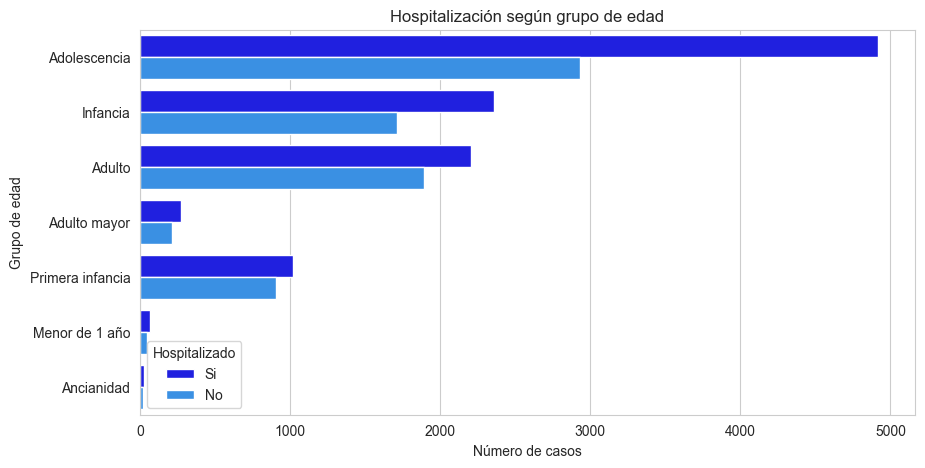

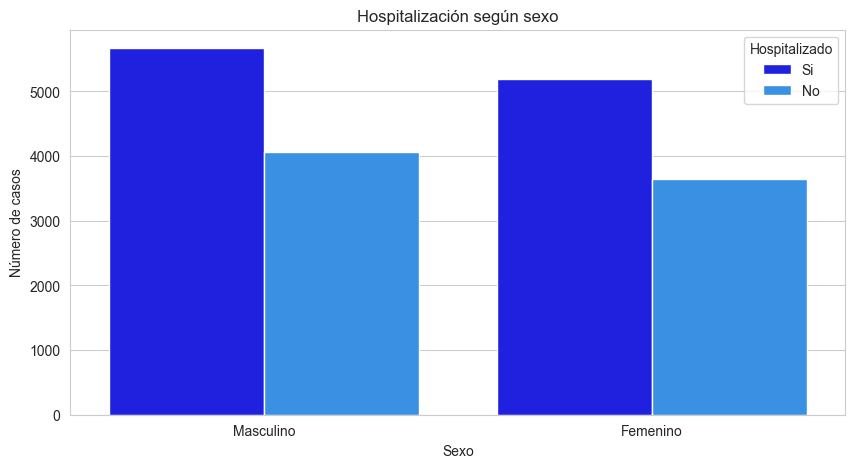

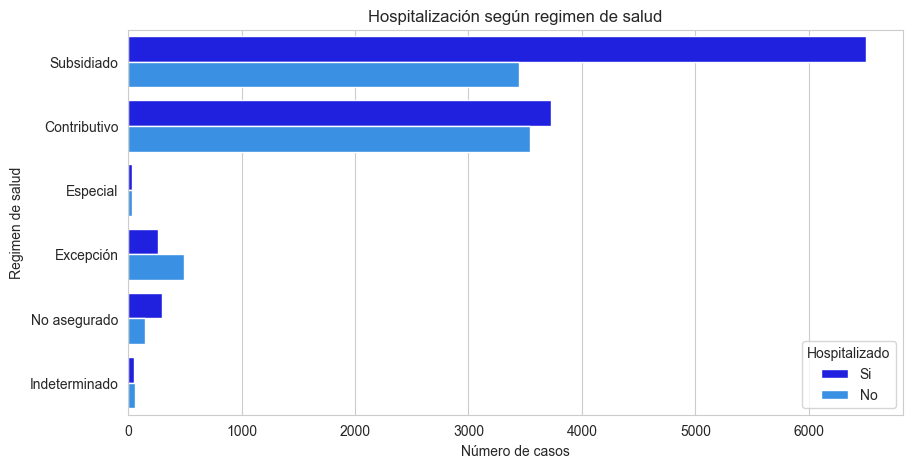

In [38]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, y="ciclo_vital", hue="hospitalizacion", palette=[ 'blue','dodgerblue'] )
plt.title("Hospitalización según grupo de edad")
plt.ylabel("Grupo de edad")
plt.xlabel("Número de casos")
plt.legend(title="Hospitalizado")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="sexo", hue="hospitalizacion", palette=[ 'blue','dodgerblue'] )
plt.title("Hospitalización según sexo")
plt.xlabel("Sexo")
plt.ylabel("Número de casos")
plt.legend(title="Hospitalizado")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(data=df, y="regimen_salud", hue="hospitalizacion", palette=[ 'blue','dodgerblue'] )
plt.title("Hospitalización según regimen de salud")
plt.ylabel("Regimen de salud")
plt.xlabel("Número de casos")
plt.legend(title="Hospitalizado")
plt.show()

#### *Tipo de caso*

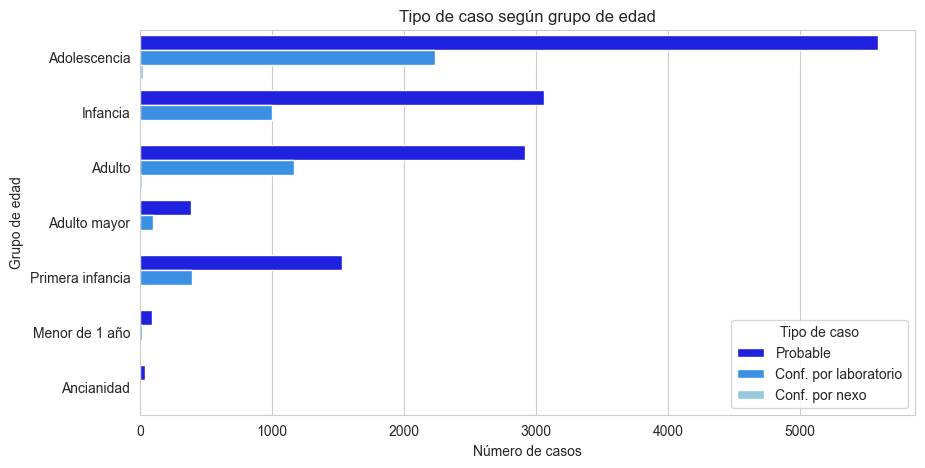

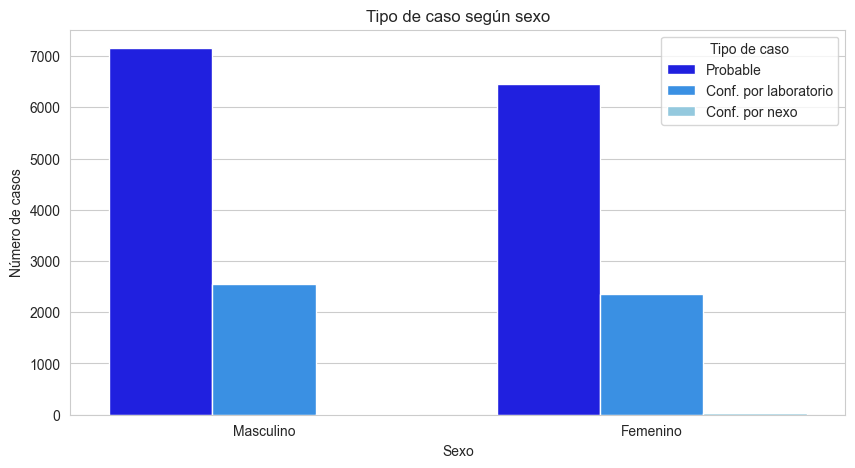

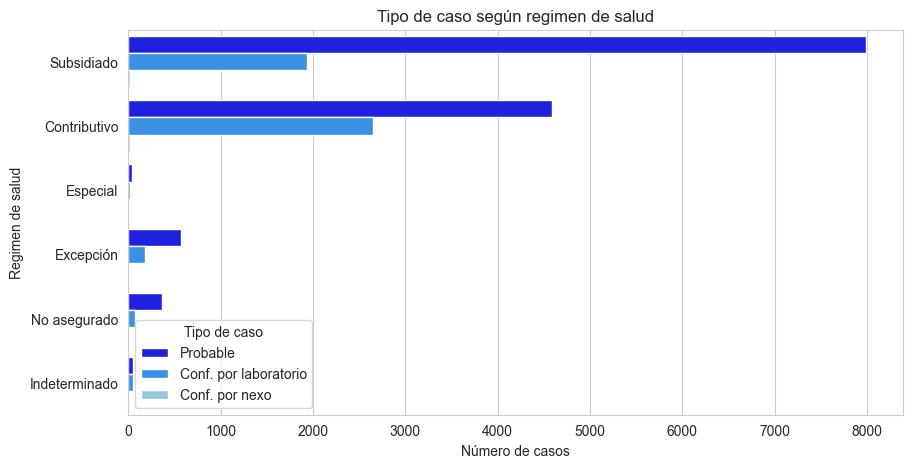

In [39]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, y="ciclo_vital", hue="tipo_de_caso", palette=[ 'blue','dodgerblue','skyblue'] )
plt.title("Tipo de caso según grupo de edad")
plt.ylabel("Grupo de edad")
plt.xlabel("Número de casos")
plt.legend(title="Tipo de caso")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="sexo", hue="tipo_de_caso", palette=[ 'blue','dodgerblue','skyblue'] )
plt.title("Tipo de caso según sexo")
plt.xlabel("Sexo")
plt.ylabel("Número de casos")
plt.legend(title="Tipo de caso")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(data=df, y="regimen_salud", hue="tipo_de_caso", palette=[ 'blue','dodgerblue','skyblue'] )
plt.title("Tipo de caso según regimen de salud")
plt.ylabel("Regimen de salud")
plt.xlabel("Número de casos")
plt.legend(title="Tipo de caso")
plt.show()

#### *Desenlace*

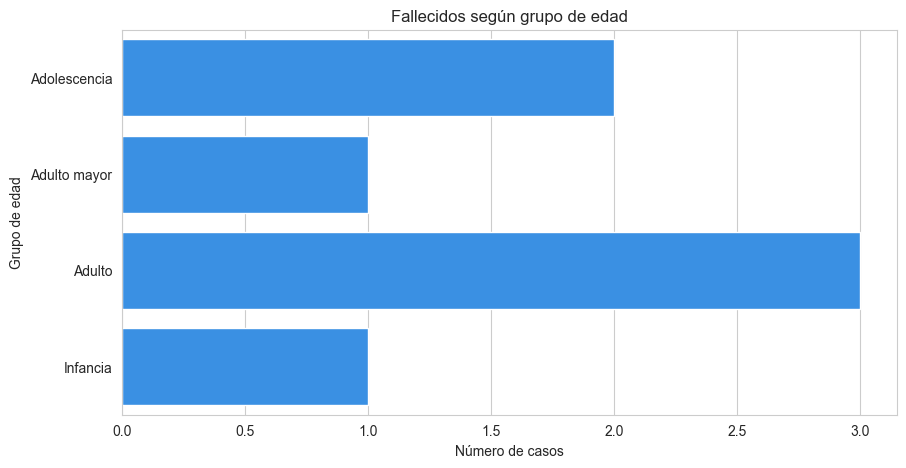

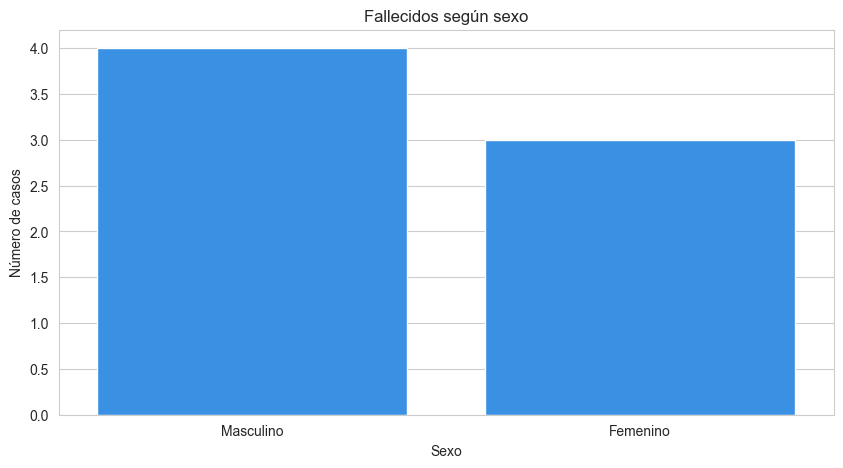

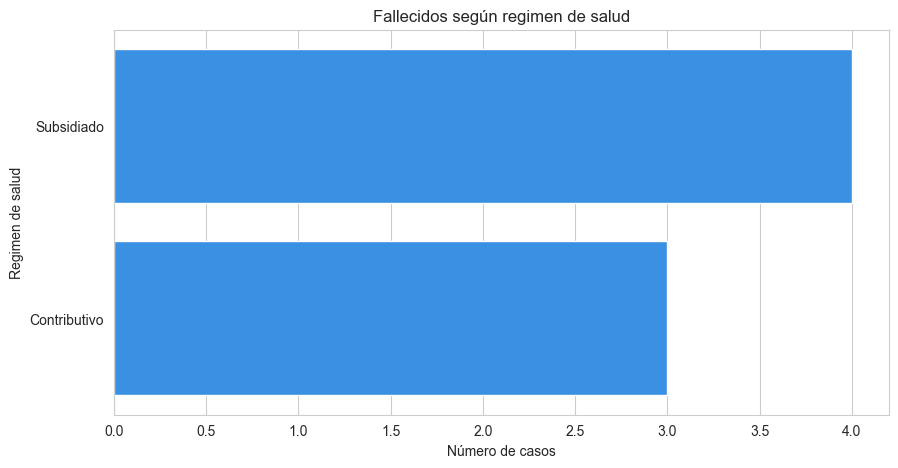

In [40]:
df_fallecidos = df[df["desenlace"] == "Fallecido"]

plt.figure(figsize=(10,5))
sns.countplot(data=df_fallecidos, y="ciclo_vital", color='dodgerblue')
plt.title("Fallecidos según grupo de edad")
plt.ylabel("Grupo de edad")
plt.xlabel("Número de casos")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(data=df_fallecidos, x="sexo", color='dodgerblue')
plt.title("Fallecidos según sexo")
plt.xlabel("Sexo")
plt.ylabel("Número de casos")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(data=df_fallecidos, y="regimen_salud", color='dodgerblue')
plt.title("Fallecidos según regimen de salud")
plt.ylabel("Regimen de salud")
plt.xlabel("Número de casos")
plt.show()

### **Temporalidad de casos**

In [41]:
# [Test] Shapiro para normalidad
stat, p = shapiro(semanas['total_casos'])
print(f"Estadístico={stat:.3f}, p-valor={p:.4f}")


Estadístico=0.849, p-valor=0.0000


Los casos de dengue por semana, de acuerdo a la prueba shapiro, no siguen una distribución normal.

In [42]:
# [Test] Kruskall Wallys para correspondencia
def comparar_casos_por_año(df, num_var='casos', cat_var='año', alpha=0.05):

    grupos = [df[df[cat_var]==g][num_var] for g in df[cat_var].unique()]
    
    # Kruskal-Wallis
    stat, p = kruskal(*grupos)
    kruskal_res = pd.DataFrame({
        'Estadístico': [stat],
        'p-valor': [p],
        'Significativo': ["★" if p <= alpha else ""]
    })
    
    # Post-hoc Dunn (solo si hay más de 2 grupos)
    if len(df[cat_var].unique()) > 2:
        posthoc = sp.posthoc_dunn(df, val_col=num_var, group_col=cat_var, p_adjust='bonferroni')
    else:
        posthoc = None
    
    return {'kruskal': kruskal_res, 'posthoc': posthoc}


resultados = comparar_casos_por_año(semanas, num_var='total_casos', cat_var='año')

print("Kruskal-Wallis:")
resultados['kruskal']

Kruskal-Wallis:


,Estadístico,p-valor,Significativo
0,171.980016,1.709937e-34,★


In [43]:
print("\nDunn post-hoc (p-valores corregidos Bonferroni):")
resultados['posthoc']


Dunn post-hoc (p-valores corregidos Bonferroni):


,2017,2018,2019,2020,2021,2022,2023
2017,1.000000e+00,1.696668e-04,6.715088e-07,2.942825e-01,8.032218e-08,3.512154e-18,8.487212e-28
2018,1.696668e-04,1.000000e+00,1.000000e+00,8.951510e-01,1.000000e+00,1.025256e-04,3.378912e-10
2019,6.715088e-07,1.000000e+00,1.000000e+00,4.069308e-02,1.000000e+00,9.675433e-03,2.989544e-07
2020,2.942825e-01,8.951510e-01,4.069308e-02,1.000000e+00,1.074953e-02,7.602006e-10,2.949031e-17
2021,8.032218e-08,1.000000e+00,1.000000e+00,1.074953e-02,1.000000e+00,4.101027e-02,3.113899e-06
2022,3.512154e-18,1.025256e-04,9.675433e-03,7.602006e-10,4.101027e-02,1.000000e+00,6.334551e-01
2023,8.487212e-28,3.378912e-10,2.989544e-07,2.949031e-17,3.113899e-06,6.334551e-01,1.000000e+00


La comparación del número de casos por semana entre los años 2017 y 2023 usando Kruskal-Wallis mostró una diferencia estadísticamente significativa (H = 171.98, p ≪ 0.001), indicando que la distribución de casos varió a lo largo del tiempo. El análisis post-hoc Dunn con corrección Bonferroni reveló que muchos años difieren significativamente entre sí; por ejemplo, 2017 presenta diferencias con 2018, 2019, 2022 y 2023, mientras que no difiere significativamente de 2020. En general, los años más recientes (2022 y 2023) muestran cambios marcados respecto a años anteriores, reflejando que la dinámica de los casos no fue constante y que ciertos periodos experimentaron aumentos o disminuciones significativas en la incidencia semanal. Esto evidencia una variación temporal clara en la distribución de casos a lo largo de los años.

In [44]:
# [Test] Mann-Kendall para los la tendencia
mann_kendall = original_test(semanas['total_casos'])

signal = semanas['total_casos'].values
algo = rpt.Pelt(model="rbf").fit(signal)
breaks = algo.predict(pen=10)


In [45]:
print(mann_kendall)
print(breaks)

Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(0.0), z=np.float64(13.044571276042761), Tau=np.float64(0.4579511397693216), s=np.float64(30255.0), var_s=np.float64(5379055.0), slope=np.float64(0.26143790849673204), intercept=np.float64(-18.450980392156865))
[85, 165, 240, 364]


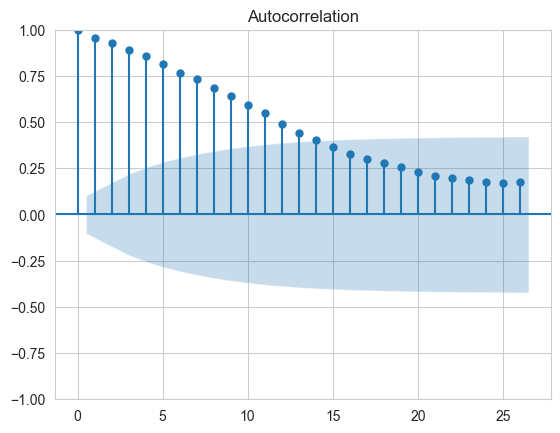

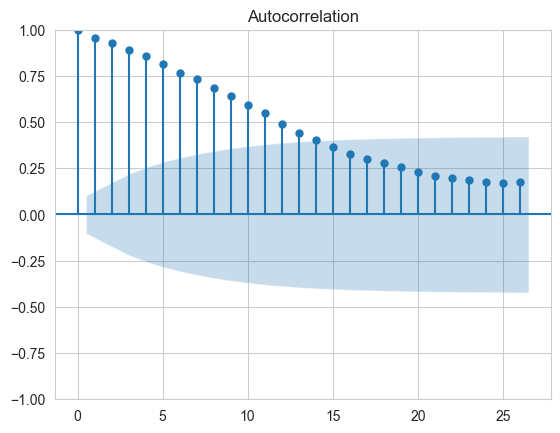

In [46]:
# [Gráfico] ACF de serie temporal
plot_acf(semanas['total_casos'])

De acuerdo con la prueba Mann-Kendall para evaluar la tendencia monotónica en el total de casos por semana epidemiológica, la serie muestra una tendencia creciente a lo largo del tiempo, rechazando la hipótesis nula de que no sigue una tendencia. El valor de correlación de Kendall indica una moderada-fuerte relación monotónica positiva (constante creciente). La mediana del cambio por semana es aproximadamente 0.26 casos adicionales por semana. De esta manera, la prueba indica que el número de casos semanales ha aumentado significativamente de manera consistente a lo largo de los años. 

El análisis de cambio estructural (breakpoint) indica que al rededor de la semana 85 (en este caso finales del 2018) hay un cambio abrupto en la media varianza de casos. Lo mismo en la semana 165, que corresponde a una de las primeras semanas del 2020. Luego en la semana 240 (finales del 2021) se tiene otro de los cambios abruptos. El último cambio estructural es la semana 364, es decir, la primera semana del año 2023. Esta variación indica que la serie no solo tiene una tendencia creciente, sino que también existen periodos donde la dinámica cambia abruptamente, lo que indica periodos de mayor brotes o años con mayor incidencia.

De acuerdo a la función de autocorrelación ACF, la serie tiene una Autocorrelación positiva decreciente, es decir, que los valores de semanas cercanas están correlacionados, y la correlación disminuye gradualmente a medida que aumenta el lag,  esto indica que los casos dependen de semanas anteriores. La autocorrelación es significativa hasta ~15 semanas. El decaimiento gradual sugiere un una tendencia. Esto indica que para las semanas cercanas, el número de casos es cercano, reflejando la forma en que la enfermedad se propaga en el tiempo.


### **Distribución de espacial de casos**

In [47]:
# [Test] Índice de Moran

#Unir con la geometría
muni = gdf.merge(casos, on="municipio")

# Crear matriz de pesos contiguos
w = Queen.from_dataframe(muni, use_index=False)
w.transform = "r"  #

y = muni['total_casos'].values
moran = Moran(y, w)

print("Índice de Moran:", moran.I)
print("Valor-p:", moran.p_sim)


Índice de Moran: 0.1705486844015851
Valor-p: 0.003


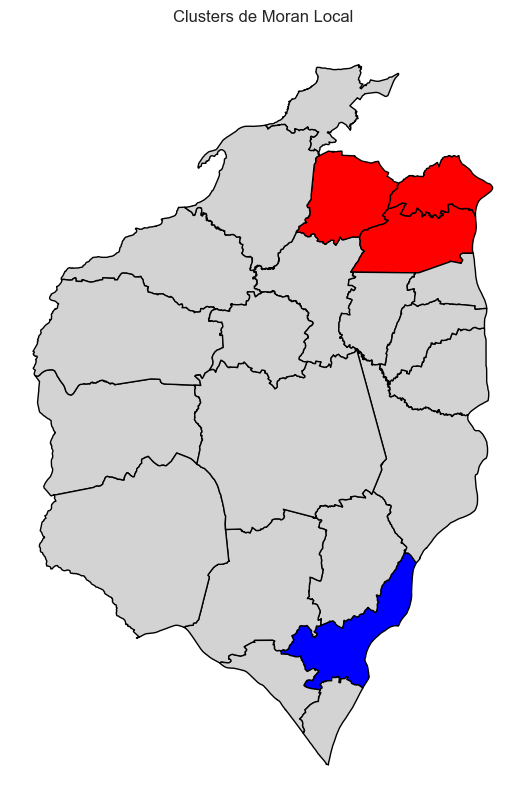

In [48]:
# Contiguos

# Crear matriz de pesos (Queen contiguidad)
w = libpysal.weights.Queen.from_dataframe(muni, use_index=False)
w.transform = "r"
moran_loc = Moran_Local(y, w)

# Signo de Moran local: High-High, Low-Low, Low-High, High-Low
muni['HH'] = (moran_loc.q==1) & (moran_loc.p_sim < 0.05)  # High-High
muni['LL'] = (moran_loc.q==3) & (moran_loc.p_sim < 0.05)  # Low-Low
muni['HL'] = (moran_loc.q==2) & (moran_loc.p_sim < 0.05)  # High-Low
muni['LH'] = (moran_loc.q==4) & (moran_loc.p_sim < 0.05)  # Low-High

# Crear una columna con el tipo de cluster
def cluster_label(row):
    if row['HH']: return 'High-High'
    elif row['LL']: return 'Low-Low'
    elif row['HL']: return 'High-Low'
    elif row['LH']: return 'Low-High'
    else: return 'No Signif'

muni['cluster'] = muni.apply(cluster_label, axis=1)

# Definir colores
colors = {
    'High-High':'red',
    'Low-Low':'blue',
    'High-Low':'orange',
    'Low-High':'lightgreen',
    'No Signif':'lightgrey'
}

# Graficar mapa
fig, ax = plt.subplots(1, 1, figsize=(10,10))
muni.plot(color=muni['cluster'].map(colors), edgecolor='black', ax=ax)
plt.title("Clusters de Moran Local")
plt.axis('off')
plt.show()

El índice de moran indica autocorrelación positiva moderada, es decir, que en los municipios con muchos casos tienden a estar cercanos entre sí, pero no es fuerte. Con el valor-p (0.009) se puede afirmar de que los casos se agregan especialmente en algunos municipios; es decir, los municipios con más casos tienden a estar cerca unos de otros. En el mapa se identifica el cluster de mayor foco de casos en los municipios de Soledad, Malambo y Galapa. El coldspots se identifica en el municipio de Santa Lucía.